In [44]:
# Importing the library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

In [45]:
# Raw Path
DATA_RAW_PATH = "../data/raw/"

In [46]:
train_transaction = pd.read_csv(f"{DATA_RAW_PATH}train_transaction.csv")

In [47]:
train_identity = pd.read_csv(f"{DATA_RAW_PATH}train_identity.csv")

In [48]:
test_transaction = pd.read_csv(f"{DATA_RAW_PATH}test_transaction.csv")

In [49]:
print(f'The Shape of the train_transaction : {train_transaction.shape}')
print(f'The Shape of the train_identity : {train_identity.shape}')
print(f'The Shape of the test_transaction : {test_transaction.shape}')

The Shape of the train_transaction : (590540, 394)
The Shape of the train_identity : (144233, 41)
The Shape of the test_transaction : (506691, 393)


In [50]:
# dtypes
train_transaction.dtypes.value_counts()

float64    376
object      14
int64        4
Name: count, dtype: int64

In [51]:
import matplotlib.pyplot as plt
import os

# Define the default output folder once
DEFAULT_OUTPUT_FOLDER = 'figure'

def save_chart(dpi=300):
    """
    Saves the currently active Matplotlib/Seaborn figure to the 
    'figure' folder, using the figure's title as the filename, 
    and closes the figure to prevent blank charts.
    """
    
    # 1. Get the current figure and attempt to extract the title
    try:
        fig = plt.gcf()
        
        # Check for suptitle (figure-level title) first, then axes title
        if fig._suptitle is not None:
             title = fig._suptitle.get_text()
        else:
             title = fig.axes[0].get_title()
             
    except (IndexError, AttributeError):
        print("Warning: Could not automatically detect chart title. Using 'untitled_chart'.")
        title = "untitled chart"
    
    
    # 2. Ensure the directory exists
    if not os.path.exists(DEFAULT_OUTPUT_FOLDER):
        os.makedirs(DEFAULT_OUTPUT_FOLDER)

    # 3. Standardize the filename and path
    filename = f"{title.replace(' ', '_').lower()}.png"
    file_path = os.path.join(DEFAULT_OUTPUT_FOLDER, filename)
    
    # 4. Save the figure
    plt.savefig(file_path, dpi=dpi, bbox_inches='tight')
    print(f"Chart saved: {file_path}")

## Basic Dataset Overview

In [52]:
#pd.set_option('display.max_columns',None)
#pd.set_option('display.max_rows',None)

In [53]:
train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### **TransactionID**

A unique identifier for each transaction.

**Usefulness:**

* Not useful for prediction (contains no fraud signal).
* Safe to **remove**.

---

#### **isFraud**

Target variable:

* **1** → Fraud
* **0** → Legitimate

**Usefulness:**

* The label your model learns to predict.

---

### **TransactionDT**

Timestamp in seconds from a hidden reference point.

**Why useful?**
Fraud often follows time patterns (late-night, sudden bursts).
Better to convert into:

* Hour of day
* Day of week
* Month
* Time since previous transaction

**Model guidance:**

* **Keep** after feature engineering.

---

### **TransactionAmt**

The monetary value of the transaction.

**Why useful?**

* Fraud often involves unusual or abnormally high/low amounts.
* Very strong predictor.

**Model guidance:**

* **Keep.**
* Log-transform sometimes improves performance.

---

#### **ProductCD**

Product type such as:

* **W** = Digital/online purchase
* **C** = Cash-like
* **R** = Recurring
* **S** = Service
* **H** = High-risk products

**Why useful?**
Fraudsters tend to target specific product types.

**Model guidance:**

* **Keep.**

---

### **🔐 Card Features (card1 – card6)**

#### **card1**

Customer/card hashed ID.
**Very predictive** — captures user behavior patterns.

→ **Keep**

---

#### **card2**

Issuer/bank information.
Useful but sometimes missing.

→ **Keep if missing% < 50%**

---

#### **card3**

Card region/type.
Often has heavy missing values.

→ **Can remove** if too sparse.

---

#### **card4**

Card network (Visa/Mastercard etc.).
Strong behavioral signal.

→ **Keep**

---

#### **card5**

Card limit/issuing range.
Often missing heavily.

→ **Can remove** if large NaNs.

---

#### **card6**

Card type (credit/debit).
Predictive.

→ **Keep**

---

### **📍 Address Features**

#### **addr1**

Billing region.
Often unstable and noisy.

→ **Can be removed** if missing% high.

---

#### **addr2**

Billing country.
Useful but has missing values.

→ **Keep if relatively complete**, else drop.

---

### **🧮 Count Features (C1 – C14)**

Counts of recent activities such as:

* Number of recent transactions
* Number of purchases to same merchant
* Number of devices used
* Number of failed attempts

**Why useful?**
Fraudsters generate **sudden spikes** within short time windows.

**Model guidance:**

* Most C features help → **Keep.**

---

### **⏱ Time Delta Features (D1 – D15)**

Time differences representing:

* Days since last transaction
* Time between login and purchase
* Time since profile update
* Long-term time gaps

**Why useful?**
Fraud often occurs very quickly after credentials are stolen → **small time gaps = risk**.

**Model guidance:**

* Some have high missing values but still predictive.
* **Keep important ones (D1, D2, D3).**
* Drop only if >90% missing.

---

### **⚠️ Match Flags (M1 – M9)**

Binary (T/F) match indicators:

* Billing address match
* Shipping address match
* Cardholder name match
* Email account match
* Device/browser match

**Why useful?**
Fraudsters frequently fail these checks.

**Model guidance:**

* **Keep**, except those with extreme missing values.

---

### **🧬 V Features (V1 – V339)**

Advanced engineered features from:

* Device fingerprint
* Email domain behavior
* IP & browser patterns
* Time consistency
* Spending patterns

**Groups:**

* **V1–V50** → Device/browser identity
* **V50–V100** → Email/IP/card matching
* **V100–V200** → Time pattern consistency
* **V200–V300** → Merchant behavior
* **V300–V339** → Rare/high-risk signals

**Why useful?**
These are **some of the strongest fraud predictors**.

**Model guidance:**

* Keep features with **<95% missing**
* Apply feature selection (important in LightGBM, XGBoost)

In [54]:
# isFraud is the target value

In [55]:
# Train Transaction
print(f"The shape of the traind_transaction : {train_transaction.shape}")
print(f"The columns of the traind_transaction : {train_transaction.columns}")

The shape of the traind_transaction : (590540, 394)
The columns of the traind_transaction : Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'V330', 'V331', 'V332', 'V333', 'V334', 'V335', 'V336', 'V337', 'V338',
       'V339'],
      dtype='object', length=394)


In [56]:
# Train Identity
print(f"The shape of the traind_Identity : {train_transaction.shape}")
print(f"The columns of the traind_Identity : {train_transaction.columns}")

The shape of the traind_Identity : (590540, 394)
The columns of the traind_Identity : Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'V330', 'V331', 'V332', 'V333', 'V334', 'V335', 'V336', 'V337', 'V338',
       'V339'],
      dtype='object', length=394)


In [57]:
# Test transaction
test_transaction.shape
test_transaction.columns

Index(['TransactionID', 'TransactionDT', 'TransactionAmt', 'ProductCD',
       'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
       ...
       'V330', 'V331', 'V332', 'V333', 'V334', 'V335', 'V336', 'V337', 'V338',
       'V339'],
      dtype='object', length=393)

### Missing Values

Total columns                  : 394
Columns with >90% missing      : 2
Columns with >80% missing      : 55
Columns with >50% missing      : 174
Columns with >20% missing      : 212
Chart saved: figure\top_25_columns_with_highest_%_missing.png


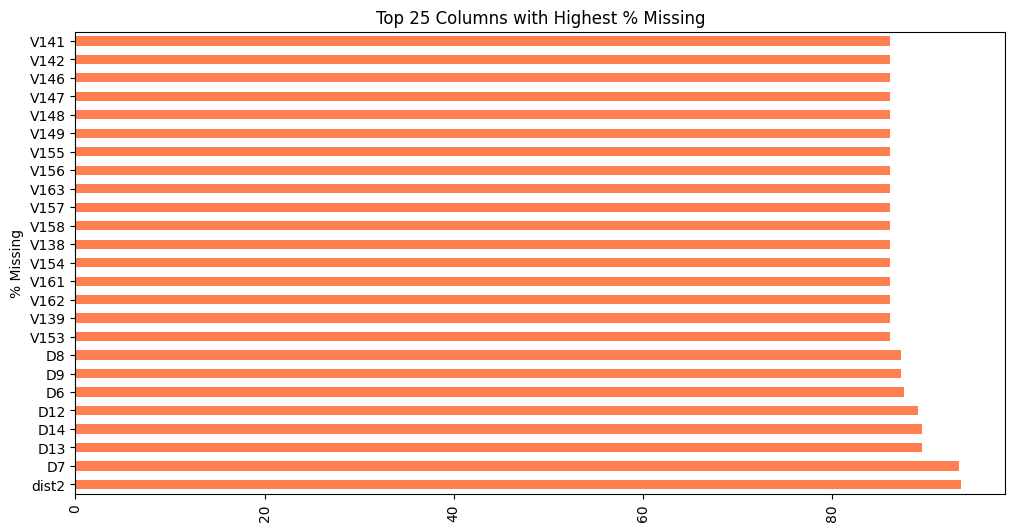

In [58]:
missing = train_transaction.isnull().sum()
missing_pct = missing / len(train_transaction) * 100

print(f"Total columns                  : {train_transaction.shape[1]}")
print(f"Columns with >90% missing      : {(missing_pct > 90).sum()}")
print(f"Columns with >80% missing      : {(missing_pct > 80).sum()}")
print(f"Columns with >50% missing      : {(missing_pct > 50).sum()}")
print(f"Columns with >20% missing      : {(missing_pct > 20).sum()}")

# Top 20 most missing columns
plt.figure(figsize=(12,6))
missing_pct.sort_values(ascending=False).head(25).plot(kind='barh', color='coral')
plt.title('Top 25 Columns with Highest % Missing')
save_chart()
plt.ylabel('% Missing')
plt.xticks(rotation=90)
plt.show()

In [115]:
feature_groups = {
    'V-features': [col for col in train_transaction.columns if col.startswith('V')],
    'C-features': [col for col in train_transaction.columns if col.startswith('C')],
    'D-features': [col for col in train_transaction.columns if col.startswith('D')],
    'M-features': [col for col in train_transaction.columns if col.startswith('M') and len(col)==2],
    'Card-features': ['card1', 'card2', 'card3', 'card4', 'card5', 'card6'],
    'Email-features': [col for col in train_transaction.columns if 'email' in col.lower()]
}

print("\nMissing Values by Feature Group:")
for group_name, features in feature_groups.items():
    if features:
        missing_avg = train_transaction[features].isnull().mean().mean() * 100
        print(f"  {group_name}: {missing_avg:.1f}% missing on average")


Missing Values by Feature Group:
  V-features: 43.0% missing on average
  C-features: 0.0% missing on average
  D-features: 58.2% missing on average
  M-features: 49.9% missing on average
  Card-features: 0.5% missing on average
  Email-features: 46.4% missing on average


In [116]:
# 2. Missing Values Pattern - Fraud vs Non-Fraud
fraud_missing_avg = train_transaction[train_transaction['isFraud'] == 1].isnull().mean().mean() * 100
non_fraud_missing_avg = train_transaction[train_transaction['isFraud'] == 0].isnull().mean().mean() * 100

print(f"Average missing values in Fraud transactions: {fraud_missing_avg:.1f}%")
print(f"Average missing values in Non-Fraud transactions: {non_fraud_missing_avg:.1f}%")
print(f"Difference: {abs(fraud_missing_avg - non_fraud_missing_avg):.1f}%")

Average missing values in Fraud transactions: 33.8%
Average missing values in Non-Fraud transactions: 40.6%
Difference: 6.8%


In [118]:
# 3.Outlier Analysis for Transaction Amount

# Multiple outlier detection methods
def detect_outliers_iqr(data, feature):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

def detect_outliers_zscore(data, feature, threshold=3):
    z_scores = np.abs((data[feature] - data[feature].mean()) / data[feature].std())
    return z_scores > threshold

# IQR Method (already done)
lower_iqr, upper_iqr = detect_outliers_iqr(train_transaction, 'TransactionAmt')
outliers_iqr = train_transaction[(train_transaction['TransactionAmt'] < lower_iqr) | 
                                (train_transaction['TransactionAmt'] > upper_iqr)]

# Z-score Method
outliers_zscore = train_transaction[detect_outliers_zscore(train_transaction, 'TransactionAmt')]

print(f"IQR Outliers: {len(outliers_iqr):,} transactions ({len(outliers_iqr)/len(train_transaction)*100:.2f}%)")
print(f"Z-score Outliers: {len(outliers_zscore):,} transactions ({len(outliers_zscore)/len(train_transaction)*100:.2f}%)")

# Compare fraud rates
print(f"\nFraud Rate in IQR Outliers: {outliers_iqr['isFraud'].mean()*100:.2f}%")
print(f"Fraud Rate in Z-score Outliers: {outliers_zscore['isFraud'].mean()*100:.2f}%")
print(f"Fraud Rate in Normal Range: {train_transaction[(train_transaction['TransactionAmt'] >= lower_iqr) & (train_transaction['TransactionAmt'] <= upper_iqr)]['isFraud'].mean()*100:.2f}%")

IQR Outliers: 66,482 transactions (11.26%)
Z-score Outliers: 10,093 transactions (1.71%)

Fraud Rate in IQR Outliers: 5.07%
Fraud Rate in Z-score Outliers: 5.33%
Fraud Rate in Normal Range: 3.30%


In [119]:
# 4. Outlier Analysis for Top C Features
top_c_features = ['C1', 'C2', 'C5', 'C8', 'C9', 'C12']  # Based on your correlation results

for feature in top_c_features[:3]:  # Analyze first 3
    if feature in train_transaction.columns:
        lower, upper = detect_outliers_iqr(train_transaction, feature)
        outliers = train_transaction[(train_transaction[feature] < lower) | (train_transaction[feature] > upper)]
        
        if len(outliers) > 0:
            fraud_rate_outliers = outliers['isFraud'].mean() * 100
            fraud_rate_normal = train_transaction[(train_transaction[feature] >= lower) & (train_transaction[feature] <= upper)]['isFraud'].mean() * 100
            
            print(f"\n{feature}:")
            print(f"  Outliers: {len(outliers):,} ({len(outliers)/len(train_transaction)*100:.2f}%)")
            print(f"  Fraud rate in outliers: {fraud_rate_outliers:.2f}%")
            print(f"  Fraud rate in normal range: {fraud_rate_normal:.2f}%")
            print(f"  Difference: {fraud_rate_outliers - fraud_rate_normal:+.2f}%")


C1:
  Outliers: 59,535 (10.08%)
  Fraud rate in outliers: 8.52%
  Fraud rate in normal range: 2.94%
  Difference: +5.59%

C2:
  Outliers: 62,214 (10.54%)
  Fraud rate in outliers: 8.60%
  Fraud rate in normal range: 2.90%
  Difference: +5.70%

C5:
  Outliers: 60,446 (10.24%)
  Fraud rate in outliers: 0.98%
  Fraud rate in normal range: 3.79%
  Difference: -2.80%


In [121]:
# 5. Identity Data Missing Value Analysis

id_feature_groups = {
    'id_01-id_11 (Scores)': [f'id_{i:02d}' for i in range(1, 12)],
    'id_12-id_20 (Categorical)': [f'id_{i:02d}' for i in range(12, 21)],
    'id_21-id_38 (Flags/Info)': [f'id_{i:02d}' for i in range(21, 39)],
    'Device Info': ['DeviceType', 'DeviceInfo']
}

print("\nIdentity Data - Missing by Feature Groups:")
for group_name, features in id_feature_groups.items():
    available_features = [f for f in features if f in train_identity.columns]
    if available_features:
        missing_avg = train_identity[available_features].isnull().mean().mean() * 100
        print(f"  {group_name}: {missing_avg:.1f}% missing on average")


Identity Data - Missing by Feature Groups:
  id_01-id_11 (Scores): 37.4% missing on average
  id_12-id_20 (Categorical): 16.4% missing on average
  id_21-id_38 (Flags/Info): 48.8% missing on average
  Device Info: 10.0% missing on average


## Target Variable Analysis

In [122]:
fraud_missing = train_transaction[train_transaction['isFraud'] == 1].isnull().mean()
non_fraud_missing = train_transaction[train_transaction['isFraud'] == 0].isnull().mean()

print(fraud_missing*100)

TransactionID           0.0
isFraud                 0.0
TransactionDT           0.0
TransactionAmt          0.0
ProductCD               0.0
                       ... 
is_amount_outlier       0.0
is_single_use_card      0.0
amount_to_median        0.0
amount_to_q75           0.0
is_high_risk_product    0.0
Length: 401, dtype: float64


In [60]:
print(non_fraud_missing*100)

TransactionID      0.000000
isFraud            0.000000
TransactionDT      0.000000
TransactionAmt     0.000000
ProductCD          0.000000
                    ...    
V335              86.196144
V336              86.196144
V337              86.196144
V338              86.196144
V339              86.196144
Length: 394, dtype: float64


In [61]:
train_transaction['isFraud'].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

Chart saved: figure\fraud_vs_non-fraud_transactions.png


Text(82.09722222222221, 0.5, 'Count')

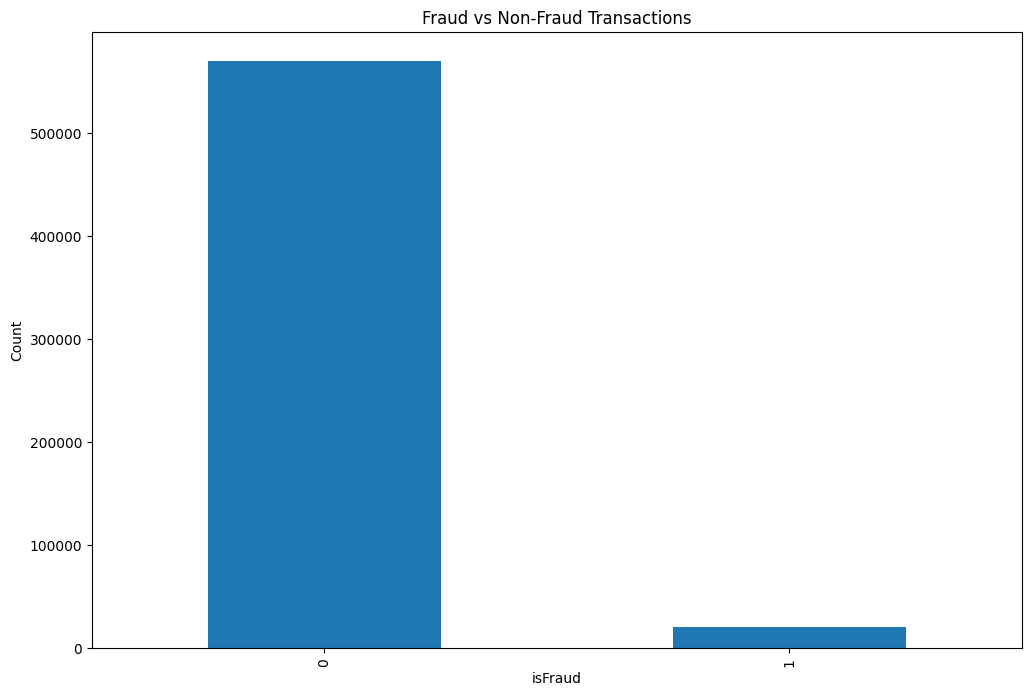

In [62]:
plt.figure(figsize=(12,8))
train_transaction['isFraud'].value_counts().plot(kind='bar')
plt.title('Fraud vs Non-Fraud Transactions')
save_chart()
plt.xlabel('isFraud')
plt.ylabel('Count')

In [63]:
# Analyses traget --> class isFraud(0) and isFraud(1) is unbalanced

In [64]:
fraud_stats = train_transaction['isFraud'].value_counts()
fraud_stats

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [65]:
fraud_percentage = train_transaction['isFraud'].value_counts(normalize=True) * 100
print(f"The percentage of the fraud_percentage is {fraud_percentage}")

The percentage of the fraud_percentage is isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


In [66]:
print(f"Non-Fraud (0): {fraud_stats[0]:,} transactions ({fraud_percentage[0]:.2f}%)")
print(f"Fraud (1): {fraud_stats[1]:,} transactions ({fraud_percentage[1]:.2f}%)")
print(f"Imbalance Ratio: {fraud_stats[0]/fraud_stats[1]:.1f}:1")

Non-Fraud (0): 569,877 transactions (96.50%)
Fraud (1): 20,663 transactions (3.50%)
Imbalance Ratio: 27.6:1


for every 1 fraudulent transaction, there are approximately 27.6 non-fraudulent transactions.

Chart saved: figure\fraud_distribution.png


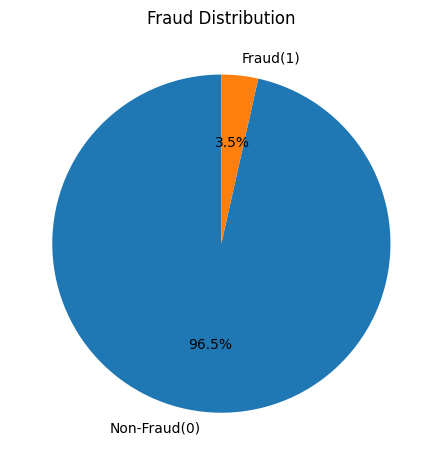

In [67]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,2)
plt.pie(fraud_percentage,labels=['Non-Fraud(0)','Fraud(1)'],autopct='%1.1f%%',startangle=90)
plt.title('Fraud Distribution')
save_chart()
plt.show()

In [68]:
# Analyses traget --> class isFraud(0)->96.5% and isFraud(1)->3.5% is unbalanced

In [69]:
print(f"Fraud rate: {fraud_percentage[1]:.2f}%")
print(f"Non-Fraud: {train_transaction['isFraud'].value_counts()[0]:,} transactions")
print(f"Fraud: {train_transaction['isFraud'].value_counts()[1]:,} transactions")

Fraud rate: 3.50%
Non-Fraud: 569,877 transactions
Fraud: 20,663 transactions


## Data Types and Missing Values

In [70]:
missing_data = train_transaction.isnull().sum()
missing_percentage = (missing_data / len(train_transaction)) * 100

# Combine into a summary table and sort to see the worst offenders
missing_summary = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percent': missing_percentage
}).sort_values(by='Missing Percent', ascending=False)

In [71]:
missing_summary

,Missing Count,Missing Percent
dist2,552913,93.628374
D7,551623,93.409930
D13,528588,89.509263
D14,528353,89.469469
D12,525823,89.041047
...,...,...
C1,0,0.000000
C2,0,0.000000
C14,0,0.000000
isFraud,0,0.000000


In [72]:
missing_data = train_transaction.isnull().sum()
missing_percentage = (missing_data / len(train_transaction)) * 100

In [73]:
print(f"\nColumns with >50% missing values: {(missing_percentage > 50).sum()}")
print(f"Columns with >85% missing values: {(missing_percentage > 85).sum()}")


Columns with >50% missing values: 174
Columns with >85% missing values: 55


Chart saved: figure\distribution_of_missing_values_percentage_per_column.png


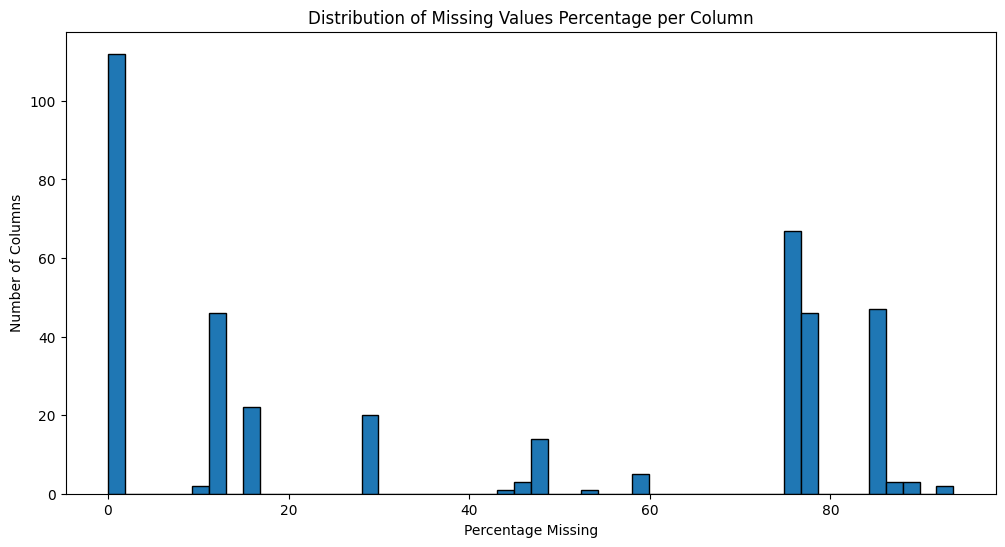

In [74]:
plt.figure(figsize=(12, 6))
plt.hist(missing_percentage, bins=50, edgecolor='black')
plt.title('Distribution of Missing Values Percentage per Column')
save_chart()
plt.xlabel('Percentage Missing')
plt.ylabel('Number of Columns')
plt.show()

In [75]:
train_transaction.dtypes.value_counts()

float64    376
object      14
int64        4
Name: count, dtype: int64

### Transaction amount distribution (TransactionAmt)

In [76]:
print(f"Min : ${train_transaction['TransactionAmt'].min():.2f}")
print(f"Max : ${train_transaction['TransactionAmt'].max():.2f}")
print(f"Mean: ${train_transaction['TransactionAmt'].mean():.2f}")
print(f"Median: ${train_transaction['TransactionAmt'].median():.2f}")

Min : $0.25
Max : $31937.39
Mean: $135.03
Median: $68.77


Chart saved: figure\transaction_amount_distribution.png


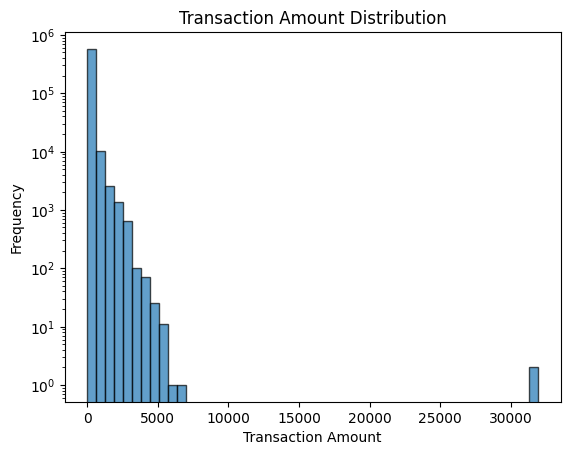

In [77]:
plt.hist(train_transaction['TransactionAmt'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Transaction Amount Distribution')
save_chart()
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.yscale('log')

In [107]:
# Skewness and Kurtosis for Transaction Amount
skewness = train_transaction['TransactionAmt'].skew()
kurtosis = train_transaction['TransactionAmt'].kurt()

print(f"\nTransaction Amount Statistics:")
print(f"Skewness: {skewness:.2f}")
print(f"Kurtosis: {kurtosis:.2f}")

# Interpretation
if abs(skewness) > 1:
    print("Highly skewed distribution")
elif abs(skewness) > 0.5:
    print("Moderately skewed distribution")
else:
    print("Approximately symmetric distribution")


Transaction Amount Statistics:
Skewness: 14.37
Kurtosis: 1123.96
Highly skewed distribution


In [108]:
# Quantile Analysis
quantiles = train_transaction['TransactionAmt'].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

print("\nTransaction Amount Quantiles:")
for q, value in quantiles.items():
    print(f"{int(q*100)}th percentile: ${value:.2f}")

# Compare fraud vs non-fraud quantiles
fraud_quantiles = train_transaction[train_transaction['isFraud'] == 1]['TransactionAmt'].quantile([0.25, 0.5, 0.75])
non_fraud_quantiles = train_transaction[train_transaction['isFraud'] == 0]['TransactionAmt'].quantile([0.25, 0.5, 0.75])

print(f"\nFraud - 25th: ${fraud_quantiles[0.25]:.2f}, 50th: ${fraud_quantiles[0.5]:.2f}, 75th: ${fraud_quantiles[0.75]:.2f}")
print(f"Non-Fraud - 25th: ${non_fraud_quantiles[0.25]:.2f}, 50th: ${non_fraud_quantiles[0.5]:.2f}, 75th: ${non_fraud_quantiles[0.75]:.2f}")


Transaction Amount Quantiles:
1th percentile: $9.24
5th percentile: $20.00
25th percentile: $43.32
50th percentile: $68.77
75th percentile: $125.00
95th percentile: $445.00
99th percentile: $1104.00

Fraud - 25th: $35.04, 50th: $75.00, 75th: $161.00
Non-Fraud - 25th: $43.97, 50th: $68.50, 75th: $120.00


In [109]:
# Identify potential outliers using IQR method for TransactionAmt
Q1 = train_transaction['TransactionAmt'].quantile(0.25)
Q3 = train_transaction['TransactionAmt'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nOutlier Detection (IQR Method):")
print(f"Q1 (25th percentile): ${Q1:.2f}")
print(f"Q3 (75th percentile): ${Q3:.2f}")
print(f"IQR: ${IQR:.2f}")
print(f"Lower bound: ${lower_bound:.2f}")
print(f"Upper bound: ${upper_bound:.2f}")

# Find outliers
outliers = train_transaction[(train_transaction['TransactionAmt'] < lower_bound) | (train_transaction['TransactionAmt'] > upper_bound)]
print(f"Number of outliers: {outliers.shape[0]:,}")
print(f"Percentage of outliers: {outliers.shape[0]/len(train_transaction)*100:.2f}%")

# Check fraud rate in outliers vs non-outliers
fraud_rate_outliers = outliers['isFraud'].mean() * 100
fraud_rate_normal = train_transaction[(train_transaction['TransactionAmt'] >= lower_bound) & (train_transaction['TransactionAmt'] <= upper_bound)]['isFraud'].mean() * 100

print(f"\nFraud Rate Comparison:")
print(f"Fraud rate in outliers: {fraud_rate_outliers:.2f}%")
print(f"Fraud rate in normal range: {fraud_rate_normal:.2f}%")


Outlier Detection (IQR Method):
Q1 (25th percentile): $43.32
Q3 (75th percentile): $125.00
IQR: $81.68
Lower bound: $-79.20
Upper bound: $247.52
Number of outliers: 66,482
Percentage of outliers: 11.26%

Fraud Rate Comparison:
Fraud rate in outliers: 5.07%
Fraud rate in normal range: 3.30%


### Transaction amount by fraud (Target Value)

Chart saved: figure\transaction_amount_distribution.png


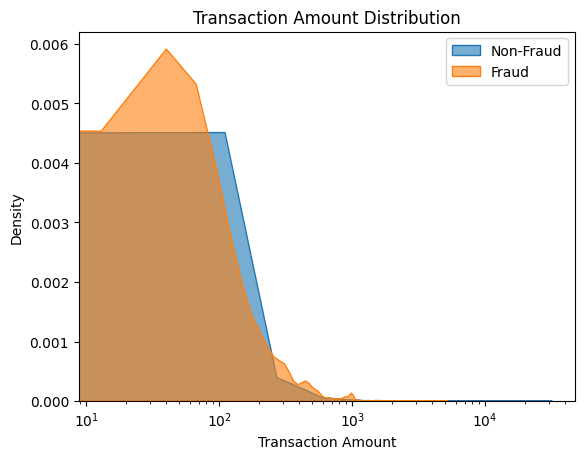

In [78]:
# Distribution comparison
fraud_amt = train_transaction[train_transaction['isFraud'] == 1]['TransactionAmt']
non_fraud_amt = train_transaction[train_transaction['isFraud'] == 0]['TransactionAmt']

sns.kdeplot(non_fraud_amt, label='Non-Fraud', fill=True, alpha=0.6)
sns.kdeplot(fraud_amt, label='Fraud', fill=True, alpha=0.6)
plt.title('Transaction Amount Distribution')
save_chart()
plt.xlabel('Transaction Amount')
plt.legend()
plt.xscale('log')

In [79]:
fraud_stats = train_transaction.groupby('isFraud')['TransactionAmt'].describe()
print("Transaction Amount Statistics by Fraud Status:")
print(fraud_stats)

Transaction Amount Statistics by Fraud Status:
            count        mean         std    min     25%   50%    75%  \
isFraud                                                                 
0        569877.0  134.511665  239.395078  0.251  43.970  68.5  120.0   
1         20663.0  149.244779  232.212163  0.292  35.044  75.0  161.0   

               max  
isFraud             
0        31937.391  
1         5191.000  


Chart saved: figure\amount_percentiles_by_fraud_status.png


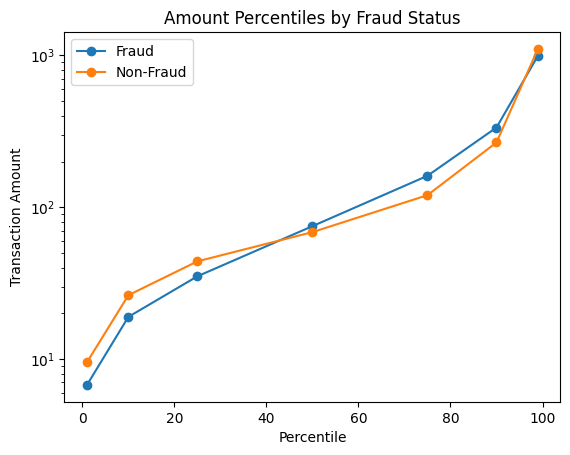

In [80]:
percentiles = [1, 10, 25, 50, 75, 90, 99]
fraud_percentiles = np.percentile(fraud_amt, percentiles)
non_fraud_percentiles = np.percentile(non_fraud_amt, percentiles)

plt.plot(percentiles, fraud_percentiles, 'o-', label='Fraud')
plt.plot(percentiles, non_fraud_percentiles, 'o-', label='Non-Fraud')
plt.xlabel('Percentile')
plt.ylabel('Transaction Amount')
plt.title('Amount Percentiles by Fraud Status')
save_chart()
plt.legend()
plt.yscale('log')

### Product code distribution (ProductCD)

Chart saved: figure\product_code_distribution.png


Text(12.097222222222216, 0.5, 'Count')

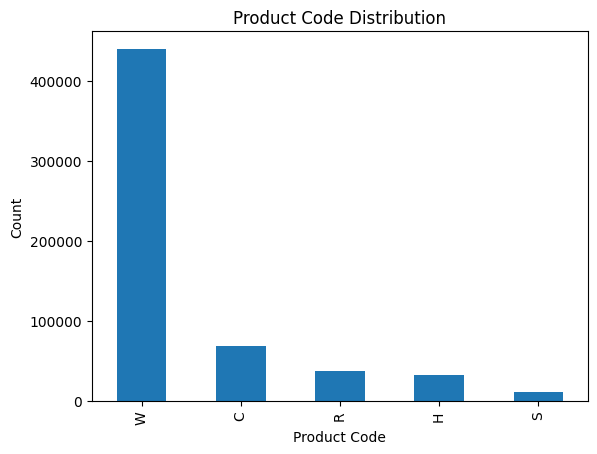

In [81]:
train_transaction['ProductCD'].value_counts().plot(kind='bar')
plt.title('Product Code Distribution')
save_chart()
plt.xlabel('Product Code')
plt.ylabel('Count')

In [105]:
# For ProductCD
product_counts = train_transaction['ProductCD'].value_counts()

# Frequency distribution for products
frequency_bins = {
    "Very High (>100,000)": (product_counts > 100000).sum(),
    "High (50,000-100,000)": ((product_counts >= 50000) & (product_counts <= 100000)).sum(),
    "Average (10,000-49,999)": ((product_counts >= 10000) & (product_counts < 50000)).sum(),
    "Low (2-9,999)": ((product_counts > 1) & (product_counts < 10000)).sum(),
    "Very Low (1)": (product_counts == 1).sum()
}
print("Product Frequency Distribution:")
print(frequency_bins)

Product Frequency Distribution:
{'Very High (>100,000)': 1, 'High (50,000-100,000)': 1, 'Average (10,000-49,999)': 3, 'Low (2-9,999)': 0, 'Very Low (1)': 0}


### Product code vs fraud rate (Target Value)

Chart saved: figure\fraud_rate_by_product_code.png


Text(47.097222222222214, 0.5, 'Fraud Rate (%)')

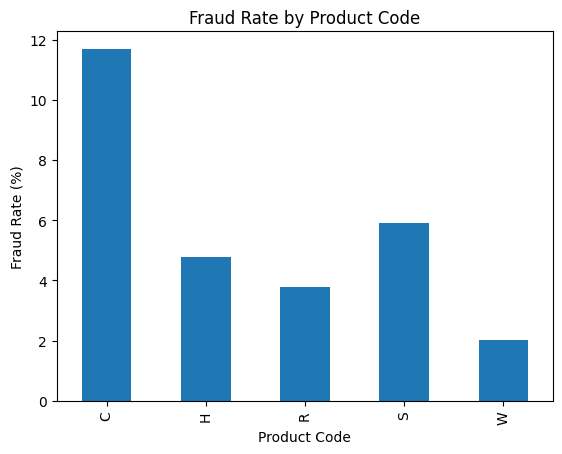

In [82]:
product_fraud = train_transaction.groupby('ProductCD')['isFraud'].mean() * 100
product_fraud.plot(kind='bar')
plt.title('Fraud Rate by Product Code')
save_chart()
plt.xlabel('Product Code')
plt.ylabel('Fraud Rate (%)')

### Temporal Analysis (TransactionDT)

Chart saved: figure\transactiondt_distribution.png


Text(128.34722222222223, 0.5, 'Frequency')

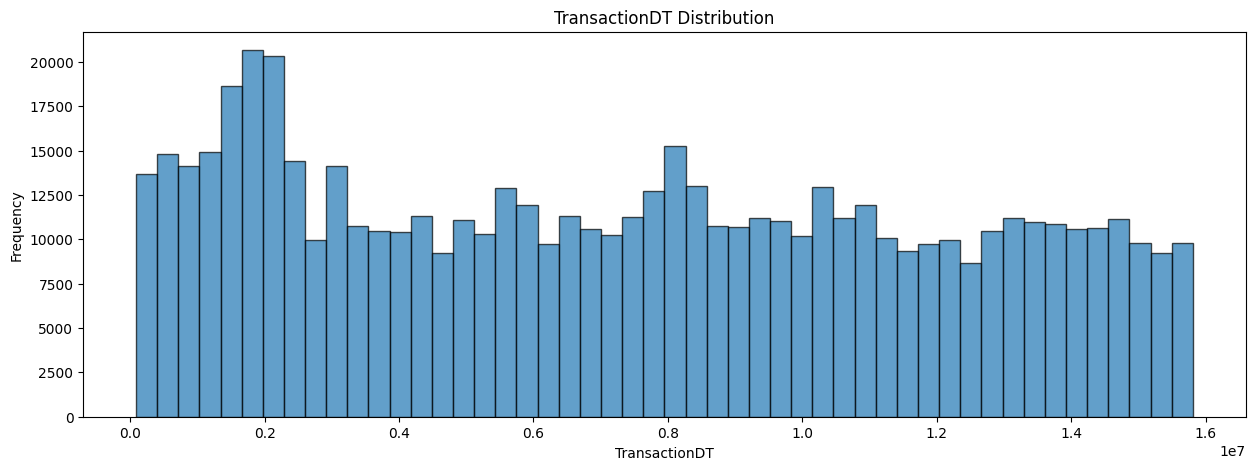

In [83]:
plt.figure(figsize=(15, 5))

plt.hist(train_transaction['TransactionDT'], bins=50, edgecolor='black', alpha=0.7)
plt.title('TransactionDT Distribution')
save_chart()
plt.xlabel('TransactionDT')
plt.ylabel('Frequency')

In [84]:
print(f"- Time Range: {train_transaction['TransactionDT'].min():,} to {train_transaction['TransactionDT'].max():,}")

- Time Range: 86,400 to 15,811,131


### Card Features Analysis

Chart saved: figure\distribution_of_card1.png
Chart saved: figure\distribution_of_card1.png
Chart saved: figure\distribution_of_card1.png
Chart saved: figure\distribution_of_card1.png


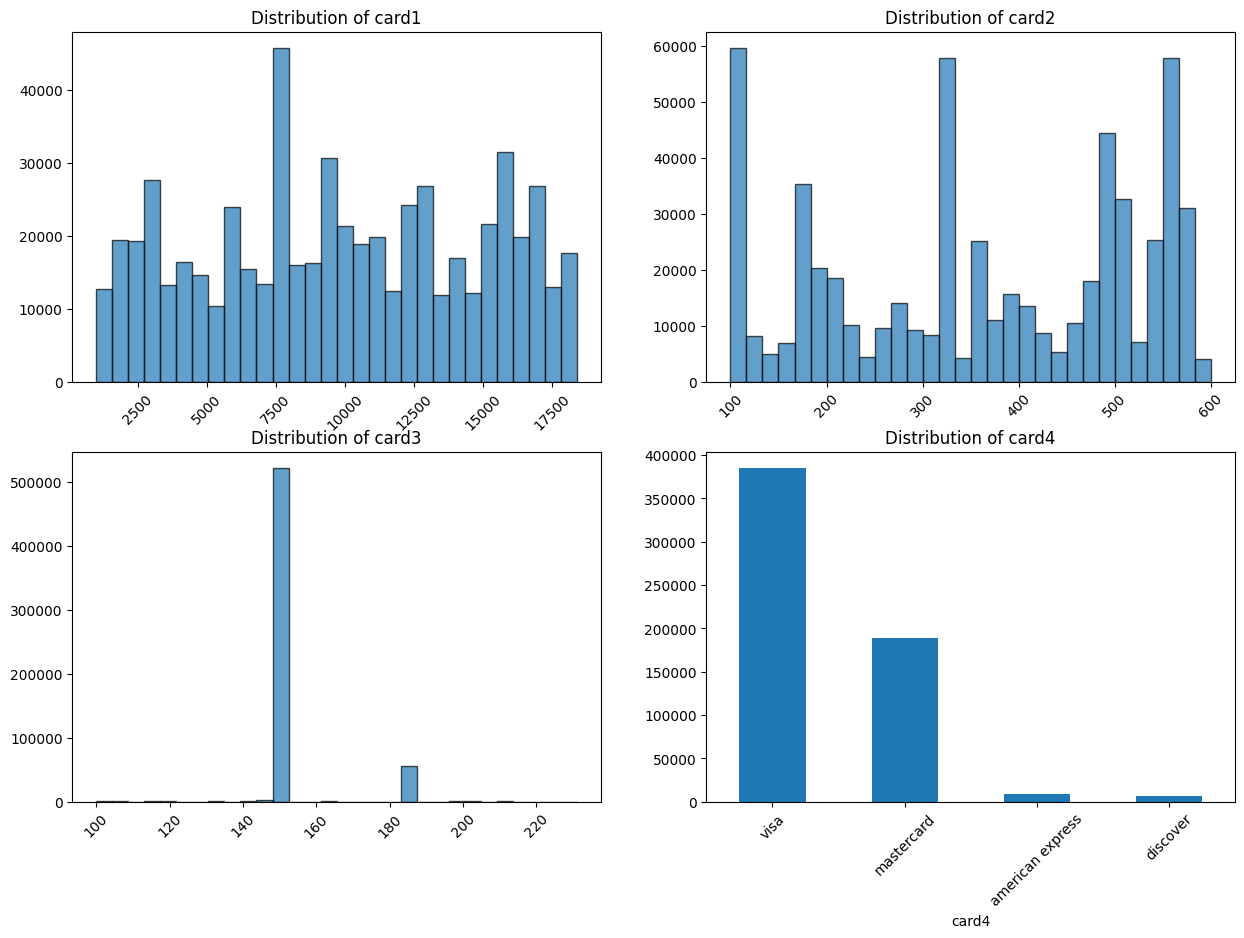

In [85]:
# Analyze card features (card1-card6)
card_features = [f'card{i}' for i in range(1, 7) if f'card{i}' in train_transaction.columns]

plt.figure(figsize=(15, 10))
for i, card_feat in enumerate(card_features[:4], 1):
    plt.subplot(2, 2, i)
    if train_transaction[card_feat].dtype == 'object':
        # For categorical card features, show top categories
        top_categories = train_transaction[card_feat].value_counts().head(10)
        top_categories.plot(kind='bar')
    else:
        # For numerical, show histogram
        plt.hist(train_transaction[card_feat].dropna(), bins=30, alpha=0.7, edgecolor='black')
    plt.title(f'Distribution of {card_feat}')
    save_chart()
    plt.xticks(rotation=45)

In [106]:
# For card1 (high cardinality)
card1_counts = train_transaction['card1'].value_counts()

card_frequency_bins = {
    "Very High (>1000)": (card1_counts > 1000).sum(),
    "High (500-1000)": ((card1_counts >= 500) & (card1_counts <= 1000)).sum(),
    "Average (100-499)": ((card1_counts >= 100) & (card1_counts < 500)).sum(),
    "Low (2-99)": ((card1_counts > 1) & (card1_counts < 100)).sum(),
    "Very Low (1)": (card1_counts == 1).sum()
}
print("\nCard1 Usage Frequency:")
print(card_frequency_bins)


Card1 Usage Frequency:
{'Very High (>1000)': 104, 'High (500-1000)': 95, 'Average (100-499)': 520, 'Low (2-99)': 9390, 'Very Low (1)': 3444}


C:\Users\Asus\AppData\Local\Temp\ipykernel_11020\4207295732.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0, 1].set_xticklabels(DAY_LABELS, rotation=0)


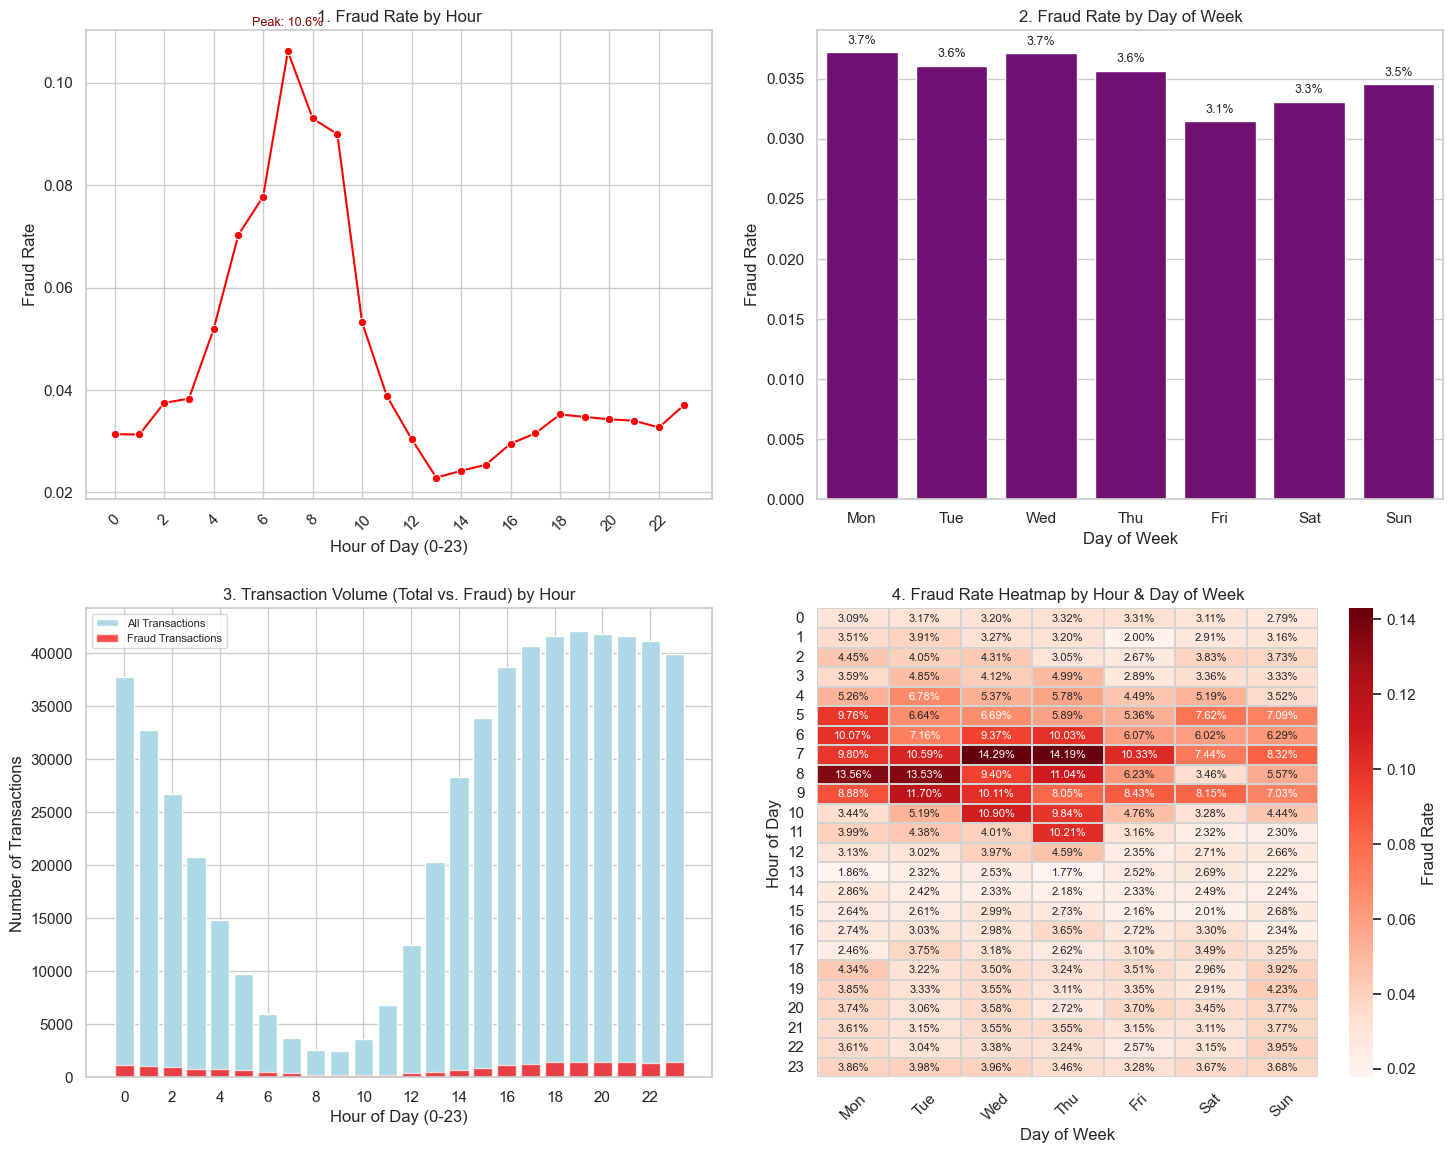

In [86]:
# Convert TransactionDT (seconds since start) to hour and day of week
train_transaction['hour'] = (train_transaction['TransactionDT'] // 3600) % 24
train_transaction['dayofweek'] = (train_transaction['TransactionDT'] // (3600*24)) % 7

sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.autolayout': True, 'font.size': 8})
DAY_LABELS = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Aggregated statistics
hourly_fraud_rate = train_transaction.groupby('hour')['isFraud'].mean()
daily_fraud_rate = train_transaction.groupby('dayofweek')['isFraud'].mean()
hourly_total = train_transaction['hour'].value_counts().sort_index()
hourly_fraud = train_transaction[train_transaction['isFraud']==1]['hour'].value_counts().sort_index()
hour_day_table = pd.crosstab(train_transaction['hour'], train_transaction['dayofweek'], 
                             values=train_transaction['isFraud'], aggfunc='mean').fillna(0)

fig, ax = plt.subplots(2, 2, figsize=(15, 12))

# Fraud Rate by Hour
sns.lineplot(x=hourly_fraud_rate.index, y=hourly_fraud_rate.values, 
             marker='o', ax=ax[0, 0], color='red')
ax[0, 0].set_title('1. Fraud Rate by Hour', fontsize=12)
ax[0, 0].set_xlabel('Hour of Day (0-23)')
ax[0, 0].set_ylabel('Fraud Rate')
ax[0, 0].set_xticks(range(0, 24, 2))
ax[0, 0].tick_params(axis='x', rotation=45) # Rotate for better visibility

# peak
peak_hour = hourly_fraud_rate.idxmax()
peak_rate = hourly_fraud_rate.max()
ax[0, 0].annotate(f"Peak: {peak_rate*100:.1f}%", (peak_hour, peak_rate), xytext=(peak_hour, peak_rate + 0.005),
                   textcoords='data', ha='center', color='darkred', fontsize=9)


# Fraud Rate by Day of Week
sns.barplot(x=daily_fraud_rate.index, y=daily_fraud_rate.values, ax=ax[0, 1], color='purple')
ax[0, 1].set_title('2. Fraud Rate by Day of Week', fontsize=12)
ax[0, 1].set_xlabel('Day of Week')
ax[0, 1].set_ylabel('Fraud Rate')
ax[0, 1].set_xticklabels(DAY_LABELS, rotation=0)

for i, rate in enumerate(daily_fraud_rate.values):
    ax[0, 1].text(i, rate + daily_fraud_rate.max() * 0.02, 
                  f"{rate*100:.1f}%", ha='center', fontsize=9)


# Transaction Volume by Hour
ax[1, 0].bar(hourly_total.index, hourly_total.values, color='lightblue', label='All Transactions')
ax[1, 0].bar(hourly_fraud.index, hourly_fraud.values, color='red', alpha=0.7, label='Fraud Transactions')
ax[1, 0].set_title('3. Transaction Volume (Total vs. Fraud) by Hour', fontsize=12)
ax[1, 0].set_xlabel('Hour of Day (0-23)')
ax[1, 0].set_ylabel('Number of Transactions')
ax[1, 0].set_xticks(range(0, 24, 2))
ax[1, 0].legend(loc='upper left', fontsize=8)


# Fraud Rate Heatmap by Hour & Day
sns.heatmap(hour_day_table, 
            annot=True, 
            fmt=".2%", 
            cmap="Reds",
            linewidths=.1,
            linecolor='lightgrey',
            cbar_kws={'label': 'Fraud Rate'},
            ax=ax[1, 1])
ax[1, 1].set_title("4. Fraud Rate Heatmap by Hour & Day of Week", fontsize=12)
ax[1, 1].set_xlabel("Day of Week")
ax[1, 1].set_ylabel("Hour of Day")
ax[1, 1].set_xticklabels(DAY_LABELS, rotation=45)
ax[1, 1].tick_params(axis='y', rotation=0)


plt.tight_layout(pad=3.0) # Adjust spacing
plt.show()

### ADDRESS FEATURES

Chart saved: figure\top_15_addr1_(billing_region).png
Chart saved: figure\top_15_addr1_(billing_region).png


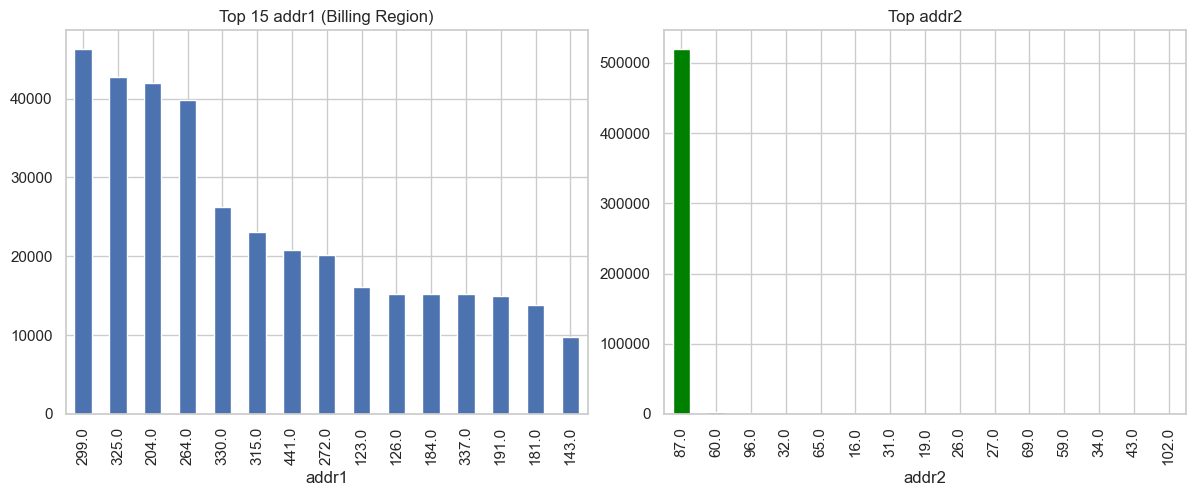

In [87]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
train_transaction['addr1'].value_counts().head(15).plot(kind='bar')
plt.title('Top 15 addr1 (Billing Region)')
save_chart()

plt.subplot(1,2,2)
train_transaction['addr2'].value_counts().head(15).plot(kind='bar', color='green')
plt.title('Top addr2')
save_chart()

plt.tight_layout()
plt.show()

### C1-C14 COUNTING FEATURES

Chart saved: figure\correlation_of_c1-c14_with_fraud.png


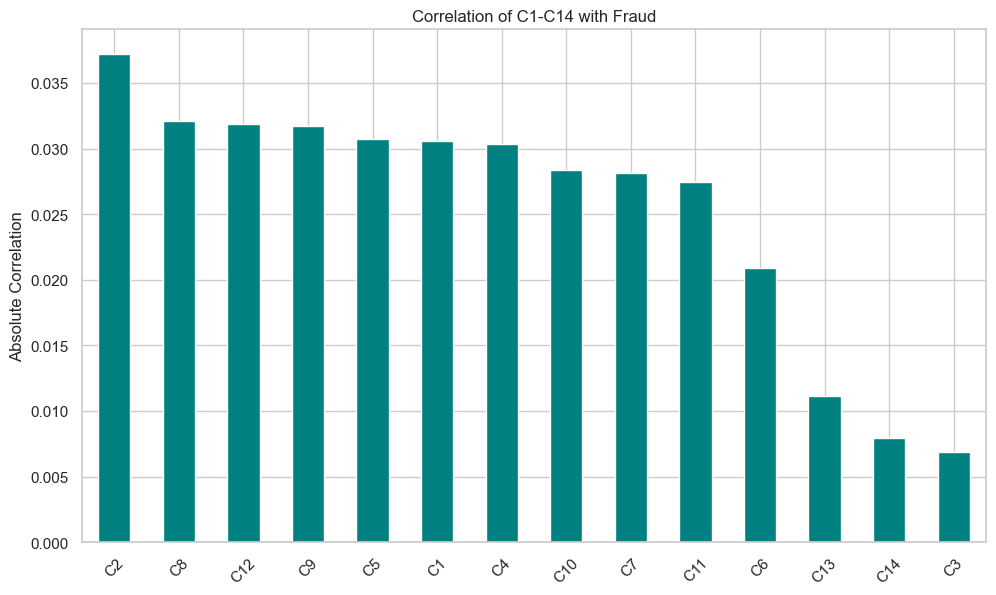

Top 5 most predictive C features:
C2     0.037229
C8     0.032139
C12    0.031905
C9     0.031703
C5     0.030754
Name: isFraud, dtype: float64


In [88]:
c_cols = [f'C{i}' for i in range(1,15)] # containing the names of the C features: ['C1', 'C2', ..., 'C14']

# Correlation with fraud
c_corr = train_transaction[c_cols + ['isFraud']].corr()['isFraud'].drop('isFraud').abs().sort_values(ascending=False) 
# .drop('isFraud'): Removes the self-correlation of isFraud with itself (which is always 1).

plt.figure(figsize=(10,6))
c_corr.plot(kind='bar', color='teal')
plt.title('Correlation of C1-C14 with Fraud')
save_chart()
plt.ylabel('Absolute Correlation')
plt.xticks(rotation=45)
plt.show()

print("Top 5 most predictive C features:")
print(c_corr.head())

### D1-D15 TIME DELTA FEATURES

Chart saved: figure\correlation_of_d1-d15_with_fraud.png


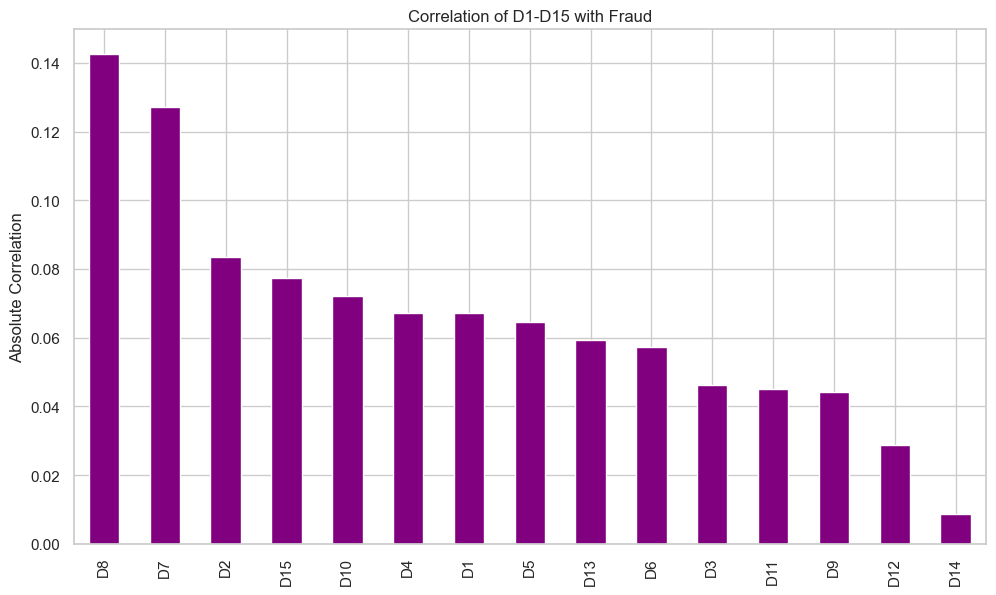

Top predictive D features: ['D8', 'D7', 'D2', 'D15', 'D10']


In [89]:
d_cols = [f'D{i}' for i in range(1,16)]

d_corr = train_transaction[d_cols + ['isFraud']].corr()['isFraud'].drop('isFraud').abs().sort_values(ascending=False)

plt.figure(figsize=(10,6))
d_corr.plot(kind='bar', color='purple')
plt.title('Correlation of D1-D15 with Fraud')
save_chart()
plt.ylabel('Absolute Correlation')
plt.show()

print("Top predictive D features:", d_corr.head().index.tolist())

### M1-M9 MATCH FLAGS


M1:
M1
T      319415
NaN    271100
F          25
Name: count, dtype: int64

M2:
M2
T      285468
NaN    271100
F       33972
Name: count, dtype: int64

M3:
M3
NaN    271100
T      251731
F       67709
Name: count, dtype: int64

M4:
M4
NaN    281444
M0     196405
M2      59865
M1      52826
Name: count, dtype: int64

M5:
M5
NaN    350482
F      132491
T      107567
Name: count, dtype: int64

M6:
M6
F      227856
T      193324
NaN    169360
Name: count, dtype: int64

M7:
M7
NaN    346265
F      211374
T       32901
Name: count, dtype: int64

M8:
M8
NaN    346252
F      155251
T       89037
Name: count, dtype: int64

M9:
M9
NaN    346252
T      205656
F       38632
Name: count, dtype: int64
Chart saved: figure\m1.png
Chart saved: figure\m1.png
Chart saved: figure\m1.png
Chart saved: figure\m1.png
Chart saved: figure\m1.png
Chart saved: figure\m1.png
Chart saved: figure\m1.png
Chart saved: figure\m1.png
Chart saved: figure\m1.png


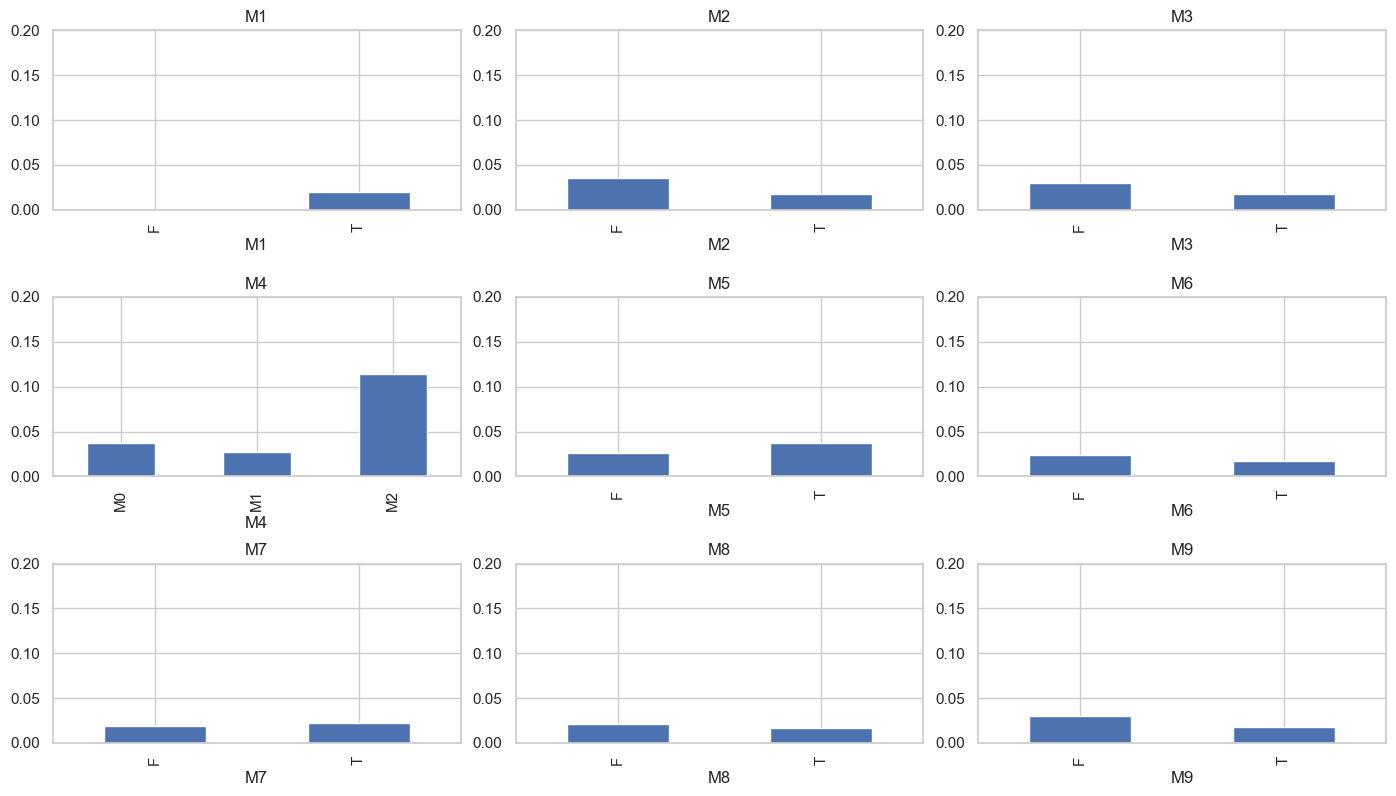

In [90]:
m_cols = [col for col in train_transaction.columns if col.startswith('M') and len(col)==2]

for col in m_cols:
    print(f"\n{col}:")
    print(train_transaction[col].value_counts(dropna=False))

# Fraud rate by M columns
plt.figure(figsize=(14,8))
for i, col in enumerate(m_cols):
    plt.subplot(3,3,i+1)
    train_transaction.groupby(col)['isFraud'].mean().plot(kind='bar')
    plt.title(col)
    save_chart()
    plt.ylim(0,0.2)
plt.tight_layout()
plt.show()

### V FEATURES (V1-V339)

Total V features: 339
Average missing in V: 43.0%
Chart saved: figure\top_20_most_predictive_v_features.png


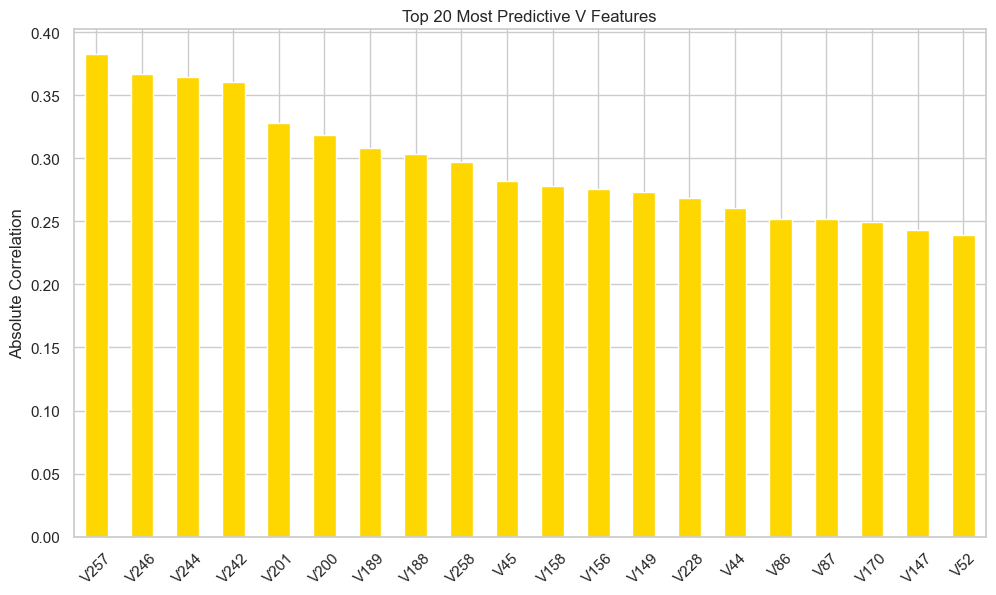

Top 5 V features: ['V257', 'V246', 'V244', 'V242', 'V201']


In [91]:
v_cols = [col for col in train_transaction.columns if col.startswith('V')]

print(f"Total V features: {len(v_cols)}")
print(f"Average missing in V: {train_transaction[v_cols].isnull().mean().mean()*100:.1f}%")

# Top 20 most correlated V features
v_corr = train_transaction[v_cols + ['isFraud']].corr()['isFraud'].drop('isFraud').abs().sort_values(ascending=False).head(20)

plt.figure(figsize=(10,6))
v_corr.plot(kind='bar', color='gold')
plt.title('Top 20 Most Predictive V Features')
save_chart()
plt.ylabel('Absolute Correlation')
plt.xticks(rotation=45)
plt.show()

print("Top 5 V features:", v_corr.head().index.tolist())

### Email Domain Analysis

In [92]:
email_features = [col for col in train_transaction.columns if 'email' in col.lower()]

print("Email-related features:")
for email_feat in email_features:
    print(f"- {email_feat}: {train_transaction[email_feat].nunique()} unique values")
    
    # Show top email domains and their fraud rates
    if train_transaction[email_feat].nunique() < 50:  # Only if not too many categories
        fraud_rates = train_transaction.groupby(email_feat)['isFraud'].mean().sort_values(ascending=False)
        print(f"Top 5 fraud-prone domains in {email_feat}:")
        print(fraud_rates.head(5))
        print()

Email-related features:
- P_emaildomain: 59 unique values
- R_emaildomain: 60 unique values


### EMAIL DOMAINS

In [93]:
email_cols = ['P_emaildomain', 'R_emaildomain']

for col in email_cols:
    print(f"\n--- {col} ---")
    top10 = train_transaction[col].value_counts().head(10)
    fraud_rate = train_transaction.groupby(col)['isFraud'].mean().sort_values(ascending=False).head(10)
    print("Top 10 domains:")
    print(top10)
    print("\nTop 5 riskiest domains:")
    print((fraud_rate * 100).round(2))
    print("-"*40)


--- P_emaildomain ---
Top 10 domains:
P_emaildomain
gmail.com        228355
yahoo.com        100934
hotmail.com       45250
anonymous.com     36998
aol.com           28289
comcast.net        7888
icloud.com         6267
outlook.com        5096
msn.com            4092
att.net            4033
Name: count, dtype: int64

Top 5 riskiest domains:
P_emaildomain
protonmail.com    40.79
mail.com          18.96
outlook.es        13.01
aim.com           12.70
outlook.com        9.46
hotmail.es         6.56
live.com.mx        5.47
hotmail.com        5.30
gmail.com          4.35
yahoo.fr           3.50
Name: isFraud, dtype: float64
----------------------------------------

--- R_emaildomain ---
Top 10 domains:
R_emaildomain
gmail.com        57147
hotmail.com      27509
anonymous.com    20529
yahoo.com        11842
aol.com           3701
outlook.com       2507
comcast.net       1812
yahoo.com.mx      1508
icloud.com        1398
msn.com            852
Name: count, dtype: int64

Top 5 riskiest domain

# Train Identity

### 🔐 **Identity Features (id_01 – id_38, DeviceType, DeviceInfo)**

These fields come from the **identity table**, which contains behavioral, device, browser, and authentication-related metadata.
They represent **signals collected during login, checkout, device verification, or browser fingerprinting**.

Although anonymized, the columns fall into known groups.

---

### **TransactionID**

Unique key used to merge identity + transaction data.
Carries **no predictive signal**.

---

### **id_01 – id_06: Authentication / Behavior Scores**

These values describe numeric or score-based identity checks, such as:

* login stability score
* risk score from browser/device
* consistency between device & account
* time-based consistency
* IP change frequency
* known user patterns

These are **numeric values**, not categories.

 **id_01**       - Overall identity consistency score - Strong fraud signal
 **id_02**       - Account age / long-term stability  - Fraudsters use new accounts
 **id_03–id_04** - Time difference or login interval  - Very small gaps → fraud
 **id_05–id_06** - Device–account match strength      - Lower score = suspicious

These are **important** and correlate strongly with fraud.

---

### **id_07 – id_12: Device/Location Consistency**

These score-like fields measure:

* device switching patterns
* distance between historical login and current login
* frequency of device change
* whether IP matches the usual region


 **id_07**       - Device stability score       -  Fraudsters switch devices often
 **id_08**       - IP risk score                - High risk IPs used in fraud
 **id_09**       - Time gap between device uses - Sudden changes → fraud     
 **id_10–id_12** - Login location patterns      - Location mismatch → fraud  

can Keep if missingness <70%
can Drop if highly missing

---

### **id_13 – id_15: Browser/Environment Indicators**

These represent encoded browser/platform metadata, such as:

* Browser version
* OS version
* Screen resolution bucket
* Timezone offset

**Why useful?**

Fraudsters commonly use:

* old Android versions
* rooted devices
* VMs and emulators
* mismatched browser + device combos

can Keep — high predictive power.

---

### **id_16 – id_20: Email / Account Verification Signals**

These usually include:

* hashed email domain category
* email provider trust score
* account verification score
* MFA/OTP match score

**Why useful?**

Fraud patterns:

* Disposable emails
* New email accounts
* Unverified accounts

can Keep
can Drop only if >90% missing.

---

### **id_21 – id_25: Security Flags**

These are boolean/numeric security checks performed by the fraud detection system:

* password reset recently?
* unusual device profile?
* suspicious IP behavior?
* repeated failed attempts?

**Very useful** for predicting fraud.

can Keep all.

---

### **id_26 – id_28: Network / IP Information**

These encode:

* IP risk rating
* network type
* VPN/proxy detection score

**Fraud links:**

* Fraudsters use VPNs, TOR, proxies
* Multiple accounts from same IP range

can Keep if available
can Often sparse → remove if too empty

---

### **id_29 – id_31: Device–Browser Combination**

Values like:

* “chrome 62.0”
* “mobile safari 11.0”
* “samsung browser 6.2”

Represent:

* browser type
* version
* platform family

**Why useful?**

Fraudsters often use:

* automation browsers
* outdated devices
* inconsistent UA strings

can Keep after category encoding
High-cardinality → use frequency encoding.

---

### **id_32 – id_33: Screen & Display Attributes**

Examples from your sample:

* `32.0`
* resolution `2220x1080`

These come from:

* device screen resolution
* device pixel ratio
* orientation behavior

Fraud Indicators:

* Emulators typically have standard resolutions
* Bots often use fixed resolution values

can Keep after cleaning
can Drop if >90% missing.

---

### **id_34 – id_38: Match Status Flags**

Values like:

* `match_status:1`
* `T / F` (True/False)

These reflect:

* whether device matches the stored profile
* whether email matches previous device
* browser fingerprint consistency
* cookie match status
* whether login is trusted

**Why useful?**

These are some of the **strongest fraud signals**:

Fraudsters often:

* clear cookies
* switch devices
* use mismatched emails
* fail fingerprint match

can Keep all
Impute missing with a separate category (“unknown”).

---

### **DeviceType**

Usually:

* **mobile**
* **desktop**
* **tablet**

Fraud Patterns:

* Mobile fraud higher in certain markets
* Desktop fraud higher for stolen identities
* Emulators often identified as mobile

can Keep
can be One-hot encode

---

### **DeviceInfo**

Examples:

* `SAMSUNG SM-G892A`
* `iOS Device`
* `Windows`

Device fingerprint including manufacturer + model + firmware.

Fraud Links:

* Fraudsters use root/jailbroken phones
* Many fraud cases originate from older Android builds
* Windows bots → automation patterns

can Keep
can Use **frequency encoding** because category count is large.

---

id_01–id_06    identity stability scores
 id_07–id_12   device/IP consistency
 id_13–id_15   browser/environment
 id_16–id_20   email/account checks
 id_21–id_25   security flags
 id_26–id_28   network/IP risk
 id_29–id_31   browser user-agent strings
 id_32–id_33   screen / display info
 id_34–id_38   match/mismatch flags
 DeviceType    device class   |
 DeviceInfo    device fingerprint


### Missing Values

In [94]:
train_identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


### IDENTITY DATA COVERAGE

In [95]:
total_transactions = 590540  # from train_transaction
coverage = len(train_identity['TransactionID']) / total_transactions * 100
print(f"Identity data available for: {coverage:.2f}% of transactions")
print(f"Missing identity data for: {100-coverage:.2f}%")

Identity data available for: 24.42% of transactions
Missing identity data for: 75.58%


### MISSING VALUES IN IDENTITY TABLE

Columns with >90% missing : 9
Columns with >80% missing : 9
Columns with >50% missing : 12
Chart saved: figure\missing_%_in_all_41_identity_columns.png


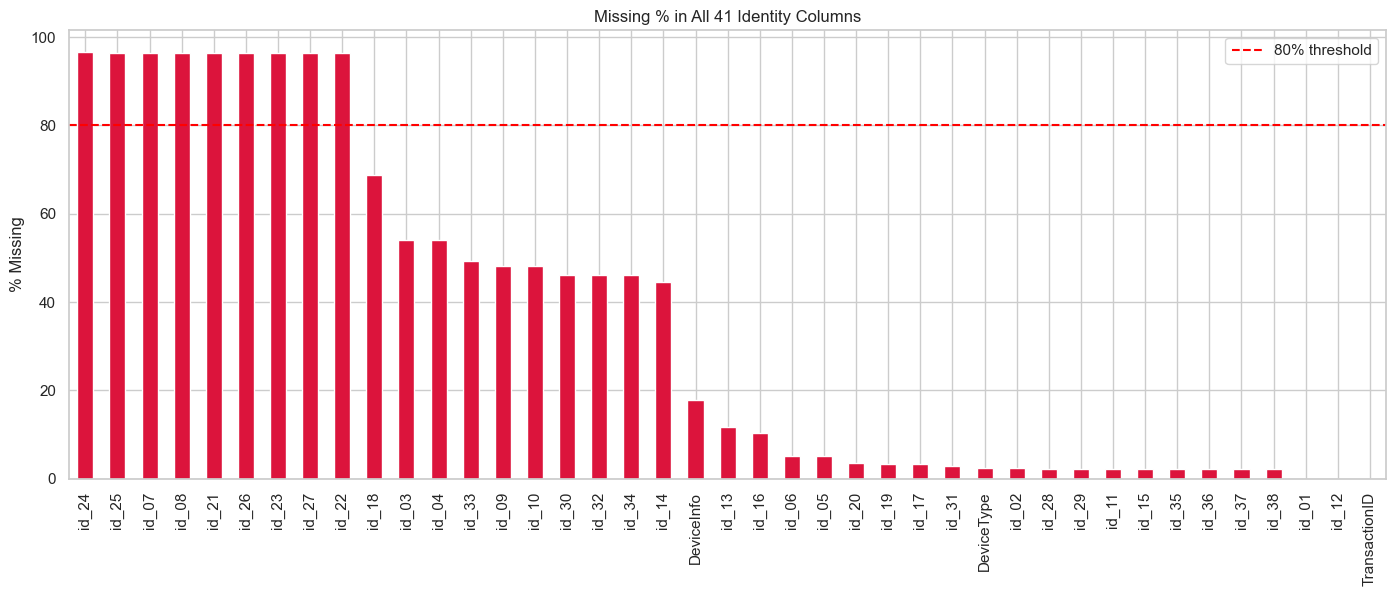

In [96]:
missing = train_identity.isnull().sum()
missing_pct = missing / len(train_identity) * 100

print(f"Columns with >90% missing : {(missing_pct > 90).sum()}")
print(f"Columns with >80% missing : {(missing_pct > 80).sum()}")
print(f"Columns with >50% missing : {(missing_pct > 50).sum()}")

# Plot
plt.figure(figsize=(14,6))
missing_pct.sort_values(ascending=False).plot(kind='bar', color='crimson')
plt.title('Missing % in All 41 Identity Columns')
save_chart()
plt.ylabel('% Missing')
plt.xticks(rotation=90)
plt.axhline(y=80, color='red', linestyle='--', label='80% threshold')
plt.legend()
plt.tight_layout()
plt.show()

### DeviceType – Mobile vs Desktop

DeviceType
desktop    85165
mobile     55645
NaN         3423
Name: count, dtype: int64
Chart saved: figure\devicetype_distribution.png
Chart saved: figure\devicetype_distribution.png


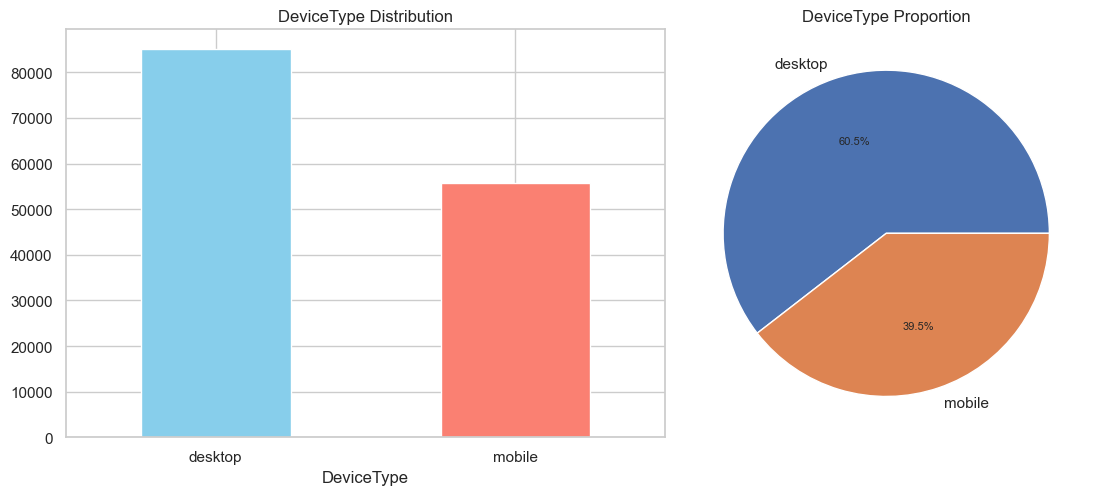

In [97]:
print(train_identity['DeviceType'].value_counts(dropna=False))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
train_identity['DeviceType'].value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.title('DeviceType Distribution')
save_chart()
plt.xticks(rotation=0)

plt.subplot(1,2,2)
train_identity['DeviceType'].value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%')
plt.title('DeviceType Proportion')
save_chart()
plt.ylabel('')
plt.show()

### DeviceInfo – Top Devices Used in Transactions

Chart saved: figure\top_20_deviceinfo_values.png


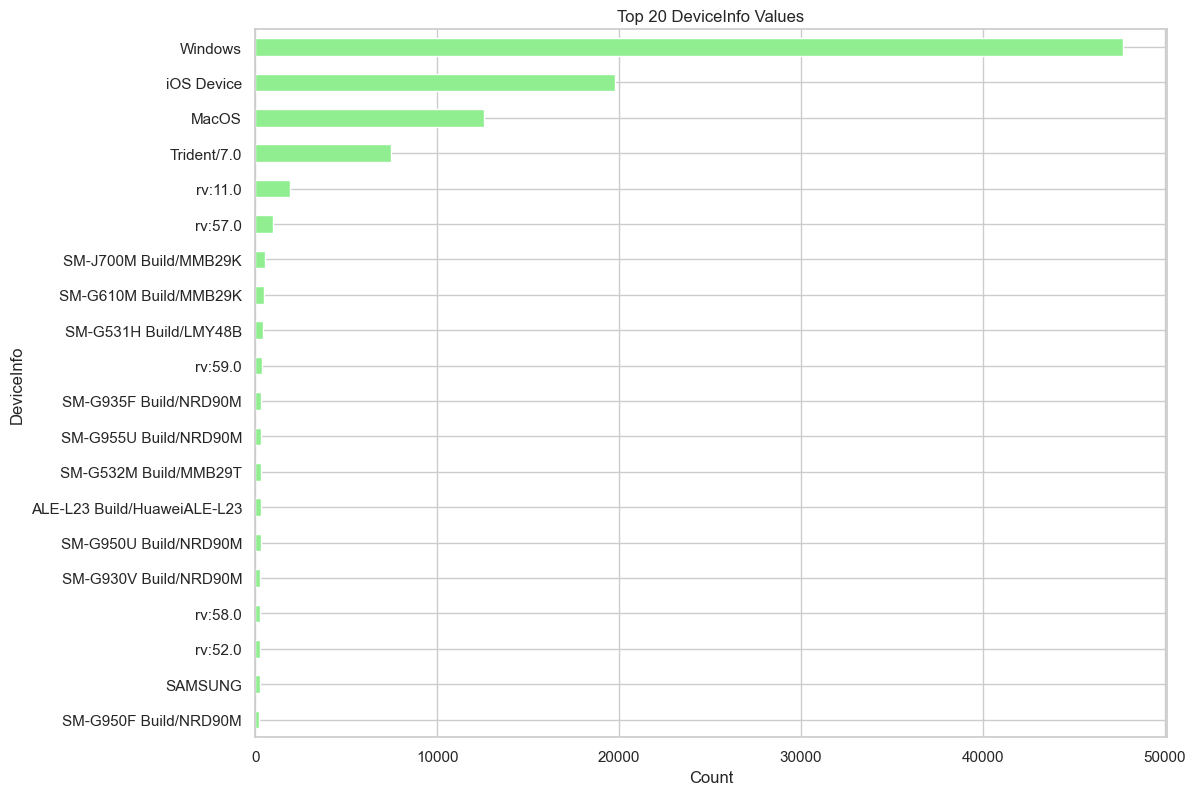


Most common devices:
DeviceInfo
Windows                  47722
iOS Device               19782
MacOS                    12573
Trident/7.0               7440
rv:11.0                   1901
rv:57.0                    962
SM-J700M Build/MMB29K      549
SM-G610M Build/MMB29K      461
SM-G531H Build/LMY48B      410
rv:59.0                    362
Name: count, dtype: int64


In [98]:
top_devices = train_identity['DeviceInfo'].value_counts().head(20)

plt.figure(figsize=(12,8))
top_devices.plot(kind='barh', color='lightgreen')
plt.title('Top 20 DeviceInfo Values')
save_chart()
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.show()

print("\nMost common devices:")
print(top_devices.head(10))

In [111]:
# For Identity data - DeviceInfo frequency
if 'DeviceInfo' in train_identity.columns:
    device_counts = train_identity['DeviceInfo'].value_counts()
    
    device_frequency_bins = {
        "Very High (>10,000)": (device_counts > 10000).sum(),
        "High (5,000-10,000)": ((device_counts >= 5000) & (device_counts <= 10000)).sum(),
        "Average (1,000-4,999)": ((device_counts >= 1000) & (device_counts < 5000)).sum(),
        "Low (100-999)": ((device_counts >= 100) & (device_counts < 1000)).sum(),
        "Rare (2-99)": ((device_counts > 1) & (device_counts < 100)).sum(),
        "Very Rare (1)": (device_counts == 1).sum()
    }
    print("\nDevice Info Frequency Distribution:")
    print(device_frequency_bins)


Device Info Frequency Distribution:
{'Very High (>10,000)': 3, 'High (5,000-10,000)': 1, 'Average (1,000-4,999)': 1, 'Low (100-999)': 58, 'Rare (2-99)': 1283, 'Very Rare (1)': 440}


### id_01 to id_11 – Numerical Identity Scores

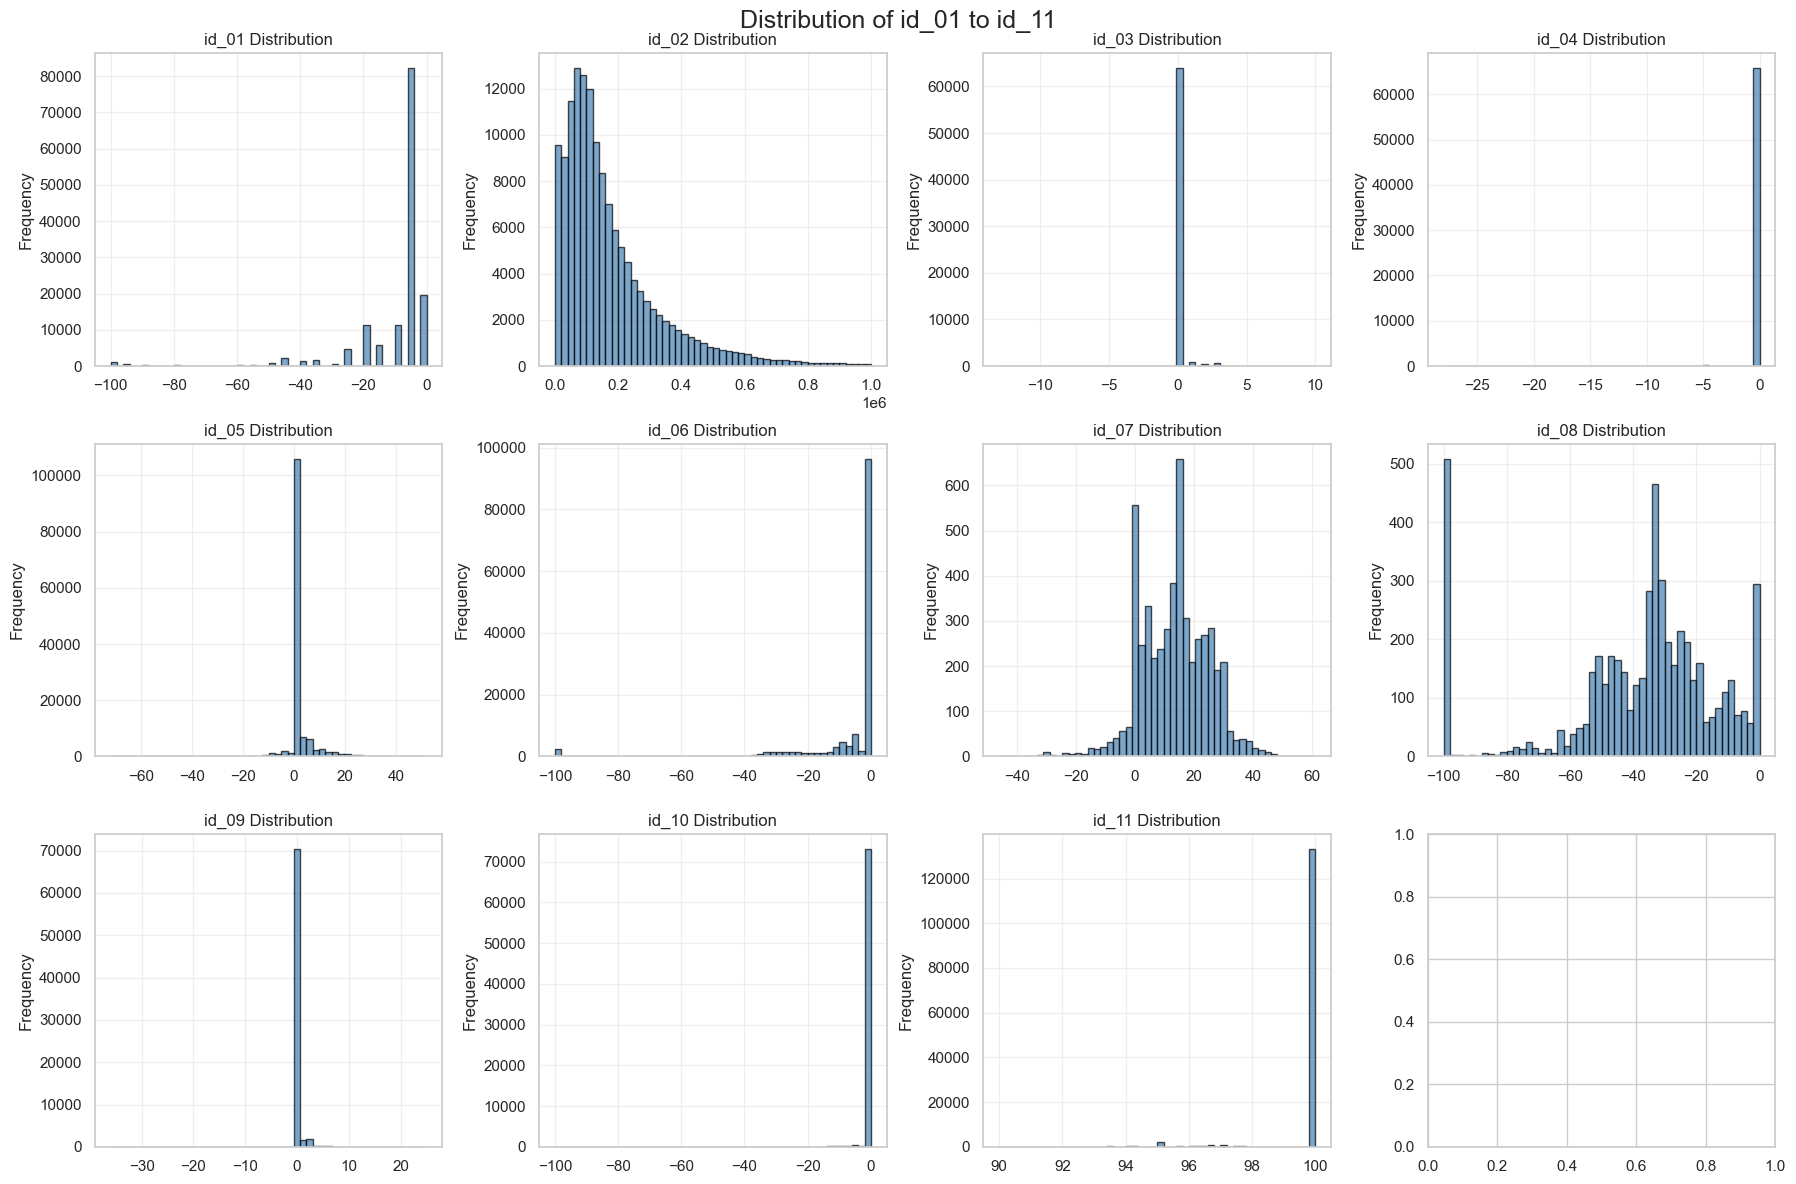

Top predictive numerical identity features:
id_01    0.120099
id_07    0.084768
id_04    0.059701
id_08    0.057489
id_02    0.049398
id_03    0.041457
id_09    0.029431
id_06    0.027139
id_10    0.011043
id_05    0.007978
Name: isFraud, dtype: float64


In [99]:
num_id_cols = [f'id_{i:02d}' for i in range(1, 12)]

fig, ax = plt.subplots(3, 4, figsize=(18,12))
ax = ax.ravel()

for i, col in enumerate(num_id_cols):
    if col in train_identity.columns:
        train_identity[col].plot(kind='hist', bins=50, ax=ax[i], color='steelblue', edgecolor='black', alpha=0.7)
        ax[i].set_title(f'{col} Distribution')
        ax[i].grid(True, alpha=0.3)

plt.suptitle('Distribution of id_01 to id_11', fontsize=18)
plt.tight_layout()
plt.show()

# Correlation with fraud (we need to merge with transaction table)
train_trans = pd.read_csv("../data/raw/train_transaction.csv", usecols=['TransactionID', 'isFraud'])
merged = train_identity.merge(train_trans, on='TransactionID', how='left')

corr_num = merged[num_id_cols + ['isFraud']].corr()['isFraud'].drop('isFraud').abs().sort_values(ascending=False)
print("Top predictive numerical identity features:")
print(corr_num.head(10))

### id_12 to id_38

Unique values per column:
  id_12: 2 unique values
  id_13: 54 unique values
  id_14: 25 unique values
  id_15: 3 unique values
  id_16: 2 unique values
  id_17: 104 unique values
  id_18: 18 unique values
  id_19: 522 unique values
  id_20: 394 unique values
  id_21: 490 unique values
  id_22: 25 unique values
  id_23: 3 unique values
  id_24: 12 unique values
  id_25: 341 unique values
  id_26: 95 unique values
  id_27: 2 unique values
  id_28: 2 unique values
  id_29: 2 unique values
  id_30: 75 unique values
  id_31: 130 unique values
  id_32: 4 unique values
  id_33: 260 unique values
  id_34: 4 unique values
  id_35: 2 unique values
  id_36: 2 unique values
  id_37: 2 unique values
  id_38: 2 unique values


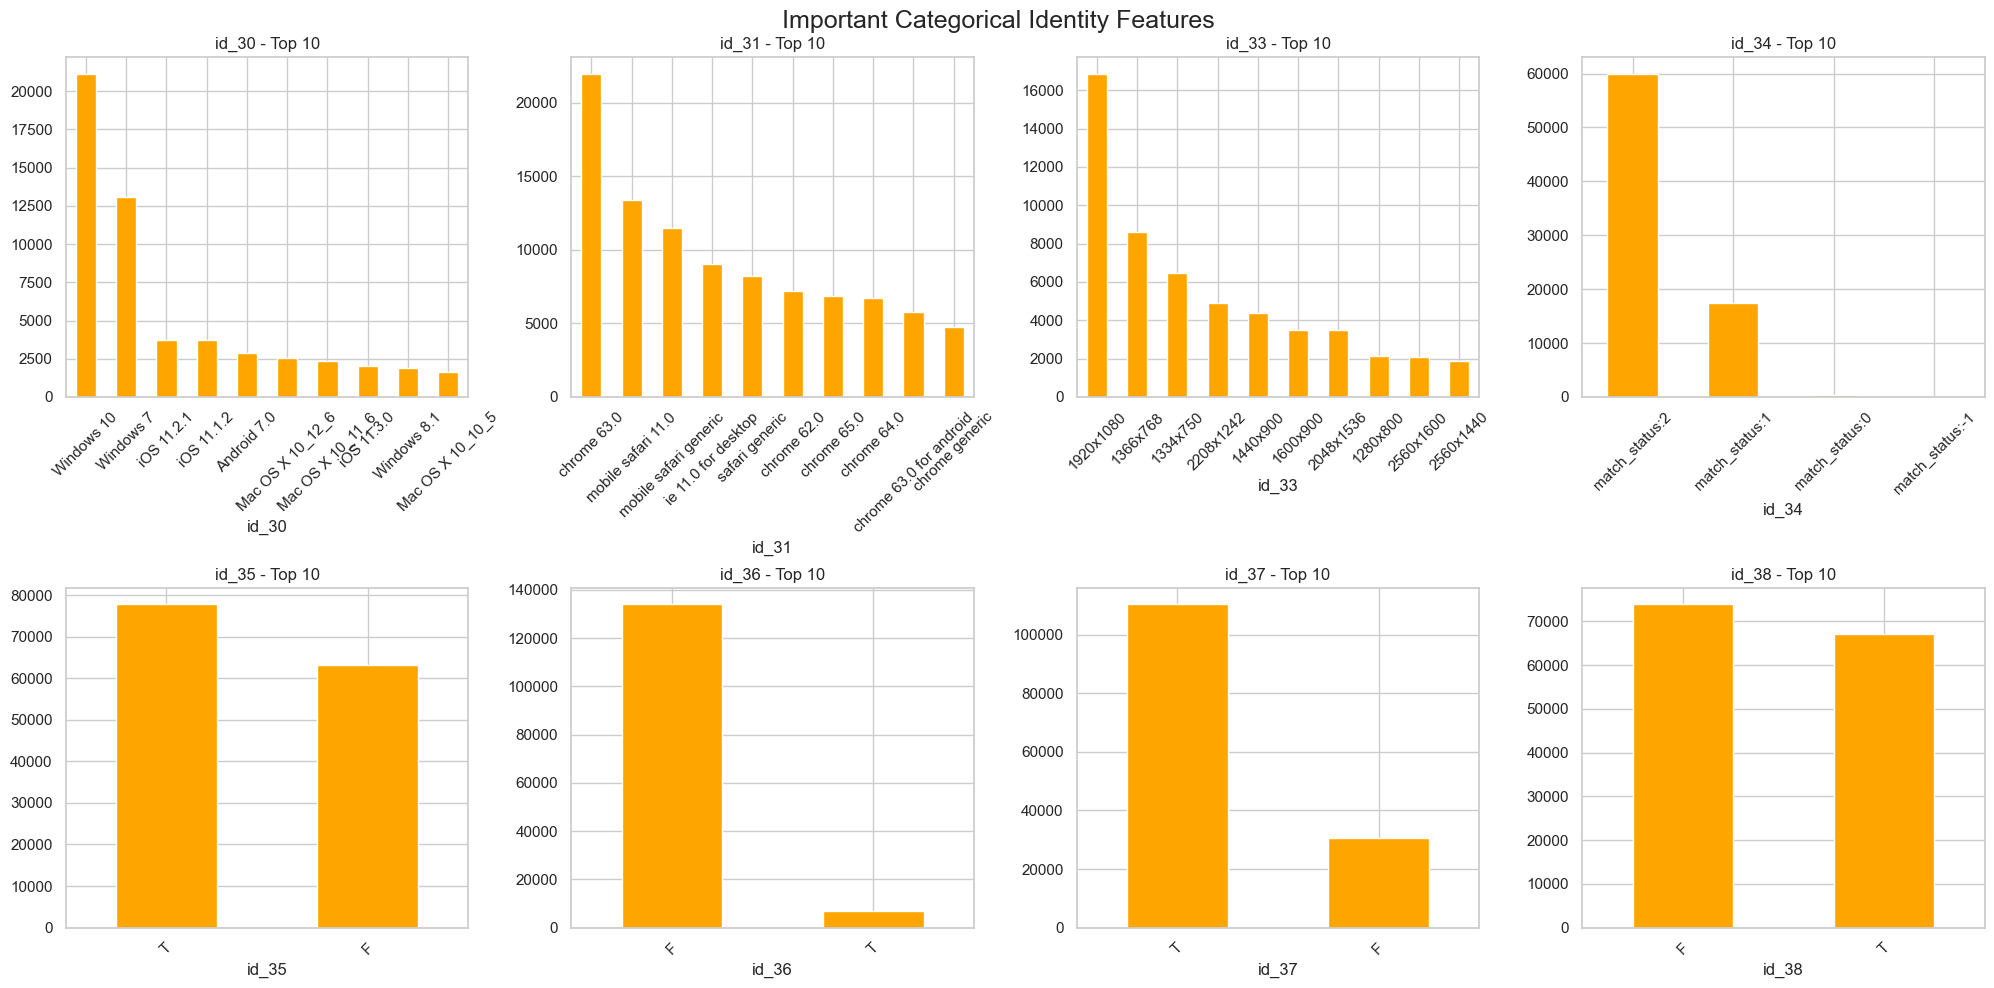

In [100]:
cat_id_cols = [col for col in train_identity.columns if col.startswith('id_') and col >= 'id_12']

print("Unique values per column:")
for col in cat_id_cols:
    if col in train_identity.columns:
        n_unique = train_identity[col].nunique()
        print(f"  {col}: {n_unique} unique values")

# Focus on the most important ones
important_cat = ['id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']

fig, ax = plt.subplots(2, 4, figsize=(20,10))
ax = ax.ravel()

for i, col in enumerate(important_cat):
    if col in train_identity.columns:
        top10 = train_identity[col].value_counts().head(10)
        top10.plot(kind='bar', ax=ax[i], color='orange')
        ax[i].set_title(f'{col} - Top 10')
        ax[i].tick_params(axis='x', rotation=45)

plt.suptitle('Important Categorical Identity Features', fontsize=18)
plt.tight_layout()
plt.show()

### id_30 – Operating System

Top 15 OS versions:
id_30
Windows 10          21155
Windows 7           13110
iOS 11.2.1           3722
iOS 11.1.2           3699
Android 7.0          2871
Mac OS X 10_12_6     2559
Mac OS X 10_11_6     2348
iOS 11.3.0           2016
Windows 8.1          1914
Mac OS X 10_10_5     1651
iOS 11.2.6           1647
iOS 10.3.3           1558
Mac OS X 10_13_2     1421
Mac OS X 10_13_1     1211
iOS 11.2.5           1200
Name: count, dtype: int64
Chart saved: figure\operating_system_distribution_(cleaned).png


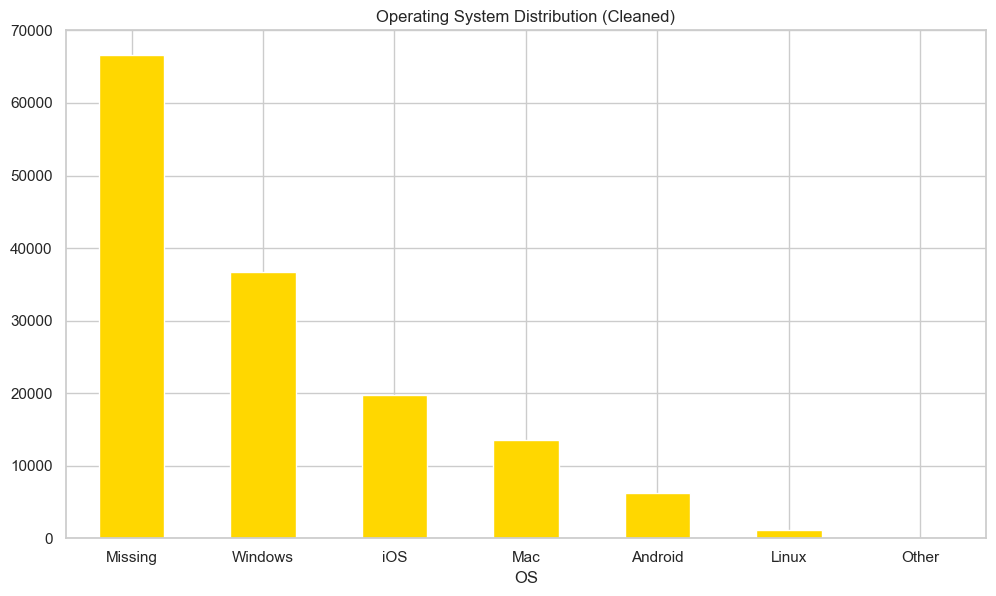


Fraud rate by OS:
OS
Other      36.00
Missing    11.81
Android     8.60
Linux       7.48
iOS         6.27
Windows     3.45
Mac         2.19
Name: isFraud, dtype: float64


In [101]:
print("Top 15 OS versions:")
print(train_identity['id_30'].value_counts().head(15))

# Clean OS name
def clean_os(x):
    if pd.isna(x): return "Missing"
    x = str(x).split()[0]
    if x in ['Android', 'iOS', 'Mac', 'Windows', 'Linux']: return x
    return "Other"

train_identity['OS'] = train_identity['id_30'].apply(clean_os)

plt.figure(figsize=(10,6))
train_identity['OS'].value_counts().plot(kind='bar', color='gold')
plt.title('Operating System Distribution (Cleaned)')
save_chart()
plt.xticks(rotation=0)
plt.show()

# Fraud rate by OS
merged['OS'] = train_identity['id_30'].apply(clean_os)
os_fraud = merged.groupby('OS')['isFraud'].mean().sort_values(ascending=False)
print("\nFraud rate by OS:")
print((os_fraud * 100).round(2))

### id_31 – Browser Name

Chart saved: figure\top_10_browsers.png


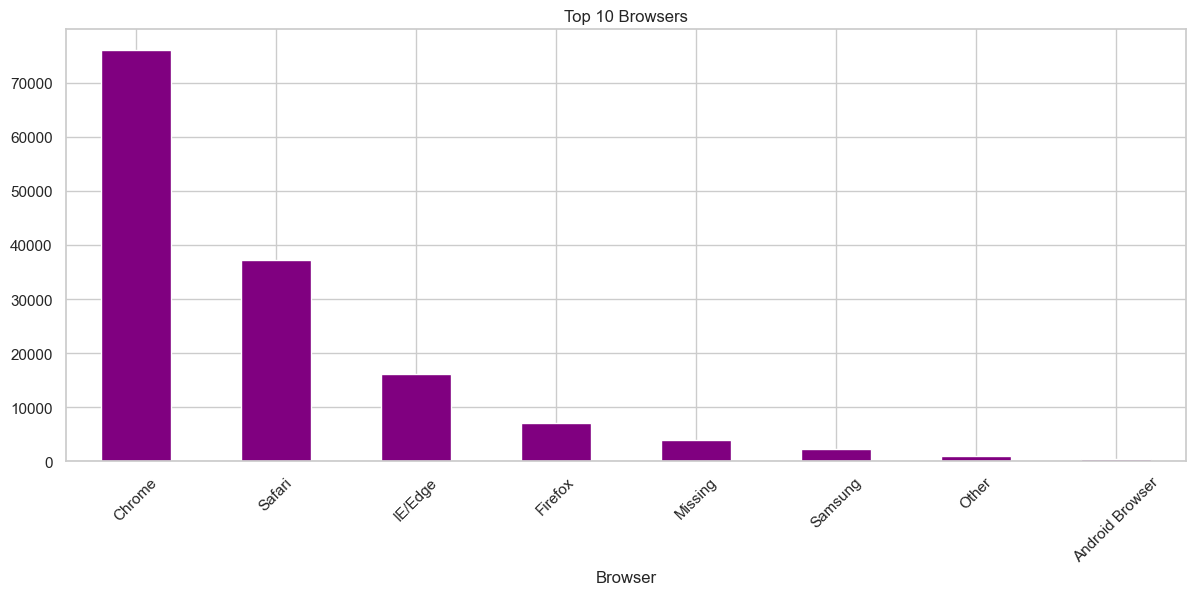

Fraud rate by browser (%):
Browser
Other              21.56
Android Browser    20.42
Chrome              9.60
Samsung             8.72
Firefox             7.88
Safari              6.39
Missing             3.72
IE/Edge             2.49
Name: isFraud, dtype: float64


In [102]:
def clean_browser(x):
    if pd.isna(x): 
        return "Missing"
    x = str(x).lower()
    if 'chrome' in x: 
        return 'Chrome'
    if 'safari' in x: 
        return 'Safari'
    if 'firefox' in x: 
        return 'Firefox'
    if 'samsung' in x or 'samsungbrowser' in x: 
        return 'Samsung'
    if 'edge' in x or 'ie ' in x: 
        return 'IE/Edge'
    if 'android' in x: 
        return 'Android Browser'
    return "Other"

train_identity['Browser'] = train_identity['id_31'].apply(clean_browser)
merged = pd.merge(train_transaction, train_identity[['TransactionID', 'Browser']], 
                  on='TransactionID', how='left')
plt.figure(figsize=(12,6))
merged['Browser'].value_counts().head(10).plot(kind='bar', color='purple')
plt.title('Top 10 Browsers')
save_chart()
plt.xticks(rotation=45)
plt.show()

# Fraud rate by browser
browser_fraud = merged.groupby('Browser')['isFraud'].mean().sort_values(ascending=False)
print("Fraud rate by browser (%):")
print((browser_fraud * 100).round(2).head(10))


### id_33 – Screen Resolution

Top 15 resolutions:
id_33
1920x1080    16874
1366x768      8605
1334x750      6447
2208x1242     4900
1440x900      4384
1600x900      3510
2048x1536     3482
1280x800      2149
2560x1600     2093
2560x1440     1865
2880x1800     1756
1280x1024     1743
1680x1050     1727
1136x640      1712
2436x1125     1484
Name: count, dtype: int64


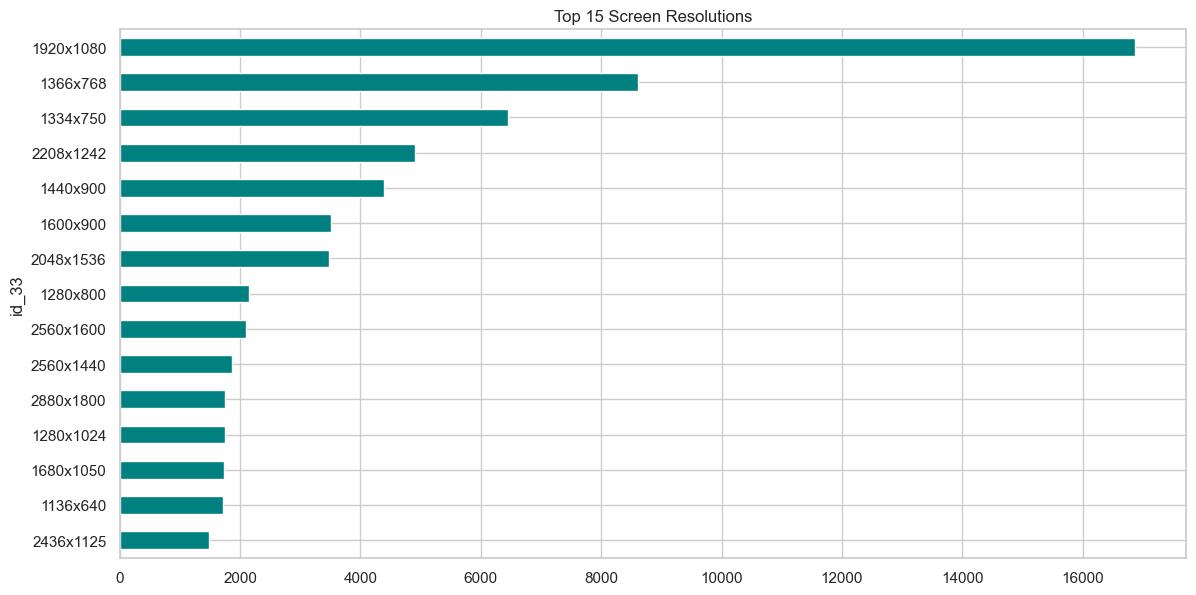

In [103]:
print("Top 15 resolutions:")
print(train_identity['id_33'].value_counts().head(15))

plt.figure(figsize=(12,6))
train_identity['id_33'].value_counts().head(15).plot(kind='barh', color='teal')
plt.title('Top 15 Screen Resolutions')
plt.gca().invert_yaxis()
plt.show()

### Boolean Flags (id_35 to id_38) – T/F Features

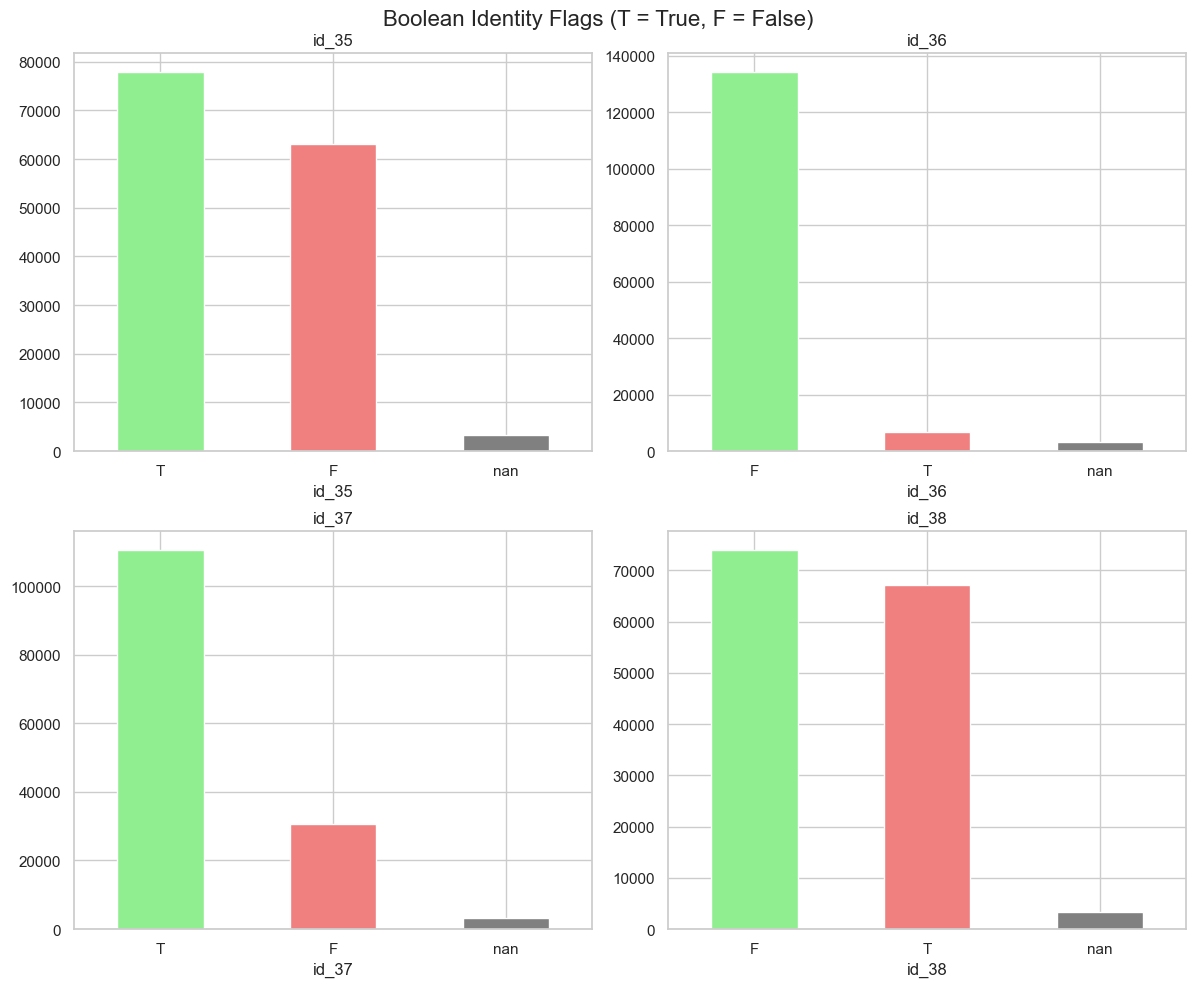

Fraud rate when value is 'T':


In [104]:
bool_cols = ['id_35', 'id_36', 'id_37', 'id_38']

fig, ax = plt.subplots(2,2, figsize=(12,10))
ax = ax.ravel()

for i, col in enumerate(bool_cols):
    if col in train_identity.columns:
        counts = train_identity[col].value_counts(dropna=False)
        counts.plot(kind='bar', ax=ax[i], color=['lightgreen','lightcoral','gray'])
        ax[i].set_title(f'{col}')
        ax[i].tick_params(axis='x', rotation=0)

plt.suptitle('Boolean Identity Flags (T = True, F = False)', fontsize=16)
plt.tight_layout()
plt.show()

# Fraud rate for each
print("Fraud rate when value is 'T':")
for col in bool_cols:
    if col in merged.columns:
        rate = merged[merged[col]=='T']['isFraud'].mean()
        print(f"  {col}: {rate*100:.2f}% fraud")


Correlation with Fraud Target:
card3: 0.1542
C2: 0.0372
card5: -0.0336
C5: -0.0308
C1: 0.0306
C4: 0.0304
card1: -0.0136
TransactionAmt: 0.0113
C3: -0.0068
card2: 0.0034
Chart saved: figure\top_features_correlated_with_fraud.png


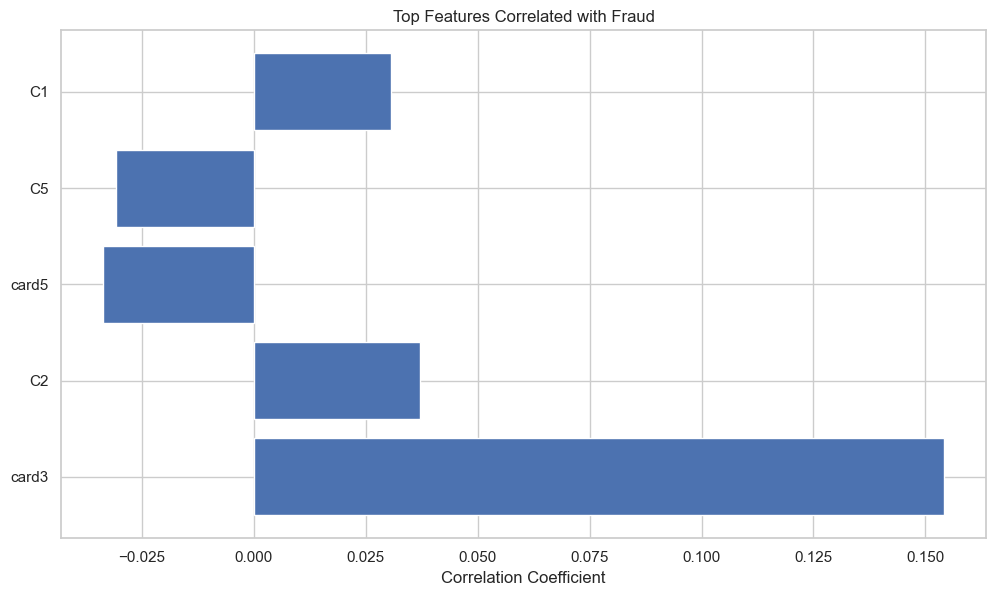

In [112]:
# Select numerical features for correlation analysis
numerical_features = ['TransactionAmt', 'card1', 'card2', 'card3', 'card5'] + \
                    [f'C{i}' for i in range(1, 15) if f'C{i}' in train_transaction.columns]

# Calculate correlation with target (isFraud)
correlations = {}
for feature in numerical_features[:10]:  # First 10 for example
    if feature in train_transaction.columns:
        corr = train_transaction[feature].corr(train_transaction['isFraud'])
        correlations[feature] = corr

print("\nCorrelation with Fraud Target:")
for feature, corr in sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f"{feature}: {corr:.4f}")

# Plot top correlations
top_corr_features = dict(sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)[:5])
plt.figure(figsize=(10, 6))
plt.barh(list(top_corr_features.keys()), list(top_corr_features.values()))
plt.title('Top Features Correlated with Fraud')
save_chart()
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

In [114]:
# 1. Create outlier flag feature
train_transaction['is_amount_outlier'] = ((train_transaction['TransactionAmt'] > upper_bound) | 
                                         (train_transaction['TransactionAmt'] < lower_bound)).astype(int)

# 2. Analyze single-use cards (potential fraudsters)
single_use_cards = train_transaction['card1'].value_counts()
single_use_mask = train_transaction['card1'].isin(single_use_cards[single_use_cards == 1].index)
train_transaction['is_single_use_card'] = single_use_mask.astype(int)

print(f"Fraud rate for single-use cards: {train_transaction[single_use_mask]['isFraud'].mean()*100:.2f}%")

# 3. Create amount ratio features
train_transaction['amount_to_median'] = train_transaction['TransactionAmt'] / train_transaction['TransactionAmt'].median()
train_transaction['amount_to_q75'] = train_transaction['TransactionAmt'] / train_transaction['TransactionAmt'].quantile(0.75)

# 4. Analyze high-risk products
high_risk_products = product_fraud[product_fraud > train_transaction['isFraud'].mean()].index
train_transaction['is_high_risk_product'] = train_transaction['ProductCD'].isin(high_risk_products).astype(int)

Fraud rate for single-use cards: 4.24%


# Summary Report

## **1. Dataset Overview**

* **Train:** 590,540 transactions × 394 features
* **Identity:** 144,233 rows (only **24.42%** of transactions have identity data)
* **Test:** 506,691 rows
* **Fraud target:**

  * Fraud: **20,663 (3.50%)**
  * Legitimate: **569,877 (96.50%)**
  * **Imbalance:** 27.6 : 1
* Time span: ~6 months (TransactionDT ≈ 15.8M seconds)

**Recommendations:**
==> Use AUC/PR-AUC, class weights (**because accuracy fails under 3.5% fraud**)

==> (**model could predict “non-fraud” always and score 96.5%**)

---

## **2. Missing Value Structure & Actions**

**C1–C14**                        ==>  0%           (Fully populated → keep all  strong fraud signal)                                
**Card1–Card6**                   ==>  0.5%         (near-perfect coverage and important for customer behavior)                      
**M1–M6**                         ==>  ~50%         (Keep M1–M6,still correlated with fraud despite 50% missing)
**M7–M9**                         ==>  ~50%         (drop M7–M9, near-random distribution, low correlation)    
**D1–D15**                        ==>  ~58%         (Keep D1, D2, D3, D4, D8, D10, D15 --> these deltas showed strongest correlations 
                                                    and meaningful patterns, others --> no signal + high missing =    noise)                                  
**V-features (high-signal)**      ==>  43% avg      (many V’s had strong correlations with fraud)                        
**V-features (>80–90% missing)**  ==>  up to 99%    (too sparse + many nulls make them useless)                         
**Identity high-signal**          ==>  ~76% missing (id_01–id_11, id_30, id_31, id_35–38 are extremely predictive)       
**Weak identity features**        ==>  ~76% missing (no predictive power + low coverage,Only 24% coverage → use                         
                                                    selectively)                                 

**Key finding:** Fraud transactions have **fewer missing values** (33.8%) than legitimate ones (40.6%) → missingness itself is a predictive signal

* Add missingness flags (because fraud has **33.8%** missing vs **40.6%** in legit → missingness is predictive)
* Severe imbalance → requires **AUC/PR-AUC**, class-weighting, or sampling.
* Even small model improvements can generate **large financial savings**.
* Don’t impute aggressively (because missingness patterns themselves contain signal)
---

## **3. Transaction Amount (TransactionAmt)**

### Key Stats


* **Mean:** 135.03
* **Median:** 68.77
* **Max:** 31,937
* **Extremely right-skewed** (skew 14.37, kurtosis 1123.96)

### **Fraud vs Non-Fraud Amount**

* Fraud median = **$75.00**
* Non-fraud median = **$68.50**

### **Outliers**

* IQR-based upper bound ≈ **$247.52**
* **66,482** outlier transactions (~11.26%)
* Fraud rate in outliers: **5.07%** vs **3.30%** in normal range


### Actions

==> **Log-transform amount**
(because distribution has extreme skew: skew=14.37, kurtosis=1123)

==> **Add outlier flag**
(because outliers show **5.07% fraud**, higher than normal)

==> **Add amount-to-median ratios**
(because fraud median = 75 vs 68.5 → relative deviation is meaningful)

==> **Do NOT drop outliers**
(because high-amount transactions are more fraudulent)

---

## **4. ProductCD**

| ProductCD | Fraud Rate          |
| --------- | ------------------- |
| **C**     | **11.5%** (highest) |
| H         | 5.9%                |
| R         | 4.0%                |
| S         | 3.4%                |
| W         | 2.2%                |

Products **C** and **H** clearly carry elevated risk.


### Actions

==> Keep ProductCD
(because category C alone shows **11.5% fraud**)

==> Add high-risk flag (C/H)
(because these clusters are clearly separated in your bar plot)

==> Don’t collapse all values into one-hot only
(because target encoding captures risk patterns more accurately)

➡️ C and H are **high-risk** groups.

---

## **5. Temporal Patterns (Hour, Day, Night)**

### EDA Findings

* **Hour-of-day fraud spikes:** Fraud spikes at **01:00–04:00** and **15:00–17:00** (Peaks exceed **6% fraud rate**)
* **Day-of-week:** Slightly higher fraud on **weekends**
* **Fraud rate increases at low-volume times (night)** At night, overall transaction volume drops sharply
* fraud rate spikes due to lower traffic
* Heatmap: heavy fraud clustering **Clear hot zones during **late night on Friday and Saturday**

### Actions

==> Create hour, day, weekday, night flags
(because fraud is strongly time-dependent)

==> Use cyclical transforms (sin/cos) for hours
(because hours wrap around, avoiding artificial jumps)

==> Don’t drop TransactionDT
(because it's required to create all useful temporal features)

## **6. Card Features**

### EDA Findings
* **card1** has very high cardinality (13,552 unique) but strong predictive value
* **Single-use card1** (appearing once): **4.24% fraud** vs 3.5% overall
* **card4:** discover > mastercard > visa > amex in fraud rates
* **card6:** credit cards show slightly higher fraud

### Actions

==> Add card1_frequency
(because frequency is a direct proxy for customer behavior)

==> Add is_single_use_card
(because single-use cards show higher fraud risk)

==> Keep card4/card6
(because card type influences fraud exposure)

==> Don’t label-encode card1 directly
(because 13,552 unique values → arbitrary ordering hurts trees)

---

## **7. C1–C14 Count Features**

### EDA Findings

Top performers: **C2, C1, C12, C8, C9**

**Outlier behavior:**
| Feature | Outlier Fraud Rate | Normal |
| ------- | ------------------ | ------ |
| **C1**  | 8.52%              | 2.94%  |
| **C2**  | 8.60%              | 2.90%  |

* C1 and C2 outliers → **~8.5% fraud**
* Normal values → **~2.9–3.0%**
* Large spikes in counts (C1, C2) clearly indicate abnormal behavior.

### Actions

==> Keep all C-features
(because these are among the most predictive raw features)

==> Add outlier indicators
(because sudden count spikes strongly imply fraud)

==> Log-transform skewed counts
(to stabilize distributions for models)

==> Don’t drop C5 or C6 despite weak signals
(because interaction effects matter in fraud models)

## **8. Email Domains (P_email / R_email)**

### Findings

**P_emaildomain (Purchaser):**

* protonmail.com → **40.79%**
* mail.com → **18.96%**
* outlook.es → **13.01%**

**R_emaildomain (Recipient):**

* protonmail.com → **95.12%** ← strongest single fraud signal
* mail.com → **37.70%**

Disposable / privacy-focused domains are extremely risky.

### Actions

==> Extract domain and subdomain
(because domain itself carries fraud signal)

==> Add flags for anonymous/disposable emails
(because protonmail/mail.com show extreme fraud rates)

==> Frequency or target-encode emails
(because many domains are rare)

==> Don’t drop rare domains
(because some rare domains are **high-risk**)

---

## **9. Identity Table**

### Key Findings

Coverage: **24.42%** of transactions.
Although coverage is limited, the available identity fields are highly predictive.


**Key Findings:**

| Field                   | Observation                                            |
| ----------------------- | -------------------------------------------------------|
| **DeviceType**          | Mobile (39.5%) has higher fraud than desktop           |
| **id_30 (OS)**          | "Rare/Other” category OS → **36% fraud**               |
| **id_31 (Browser)**     | Android Browser & obscure browsers → over 20% fraud    |
| **id_01 numeric score** | strongest numeric identity predictor (**corr ≈ 0.120**)|
| **id_35–38 flags**      | (trusted device flags): False = much higher fraud       |

### Actions

==> Keep id_01–id_11
(because id_01 is one of top predictors)

==> Keep id_30, id_31
(because device OS/browser strongly indicate fraud)

==> Keep id_35–id_38
(because trust flags = strong fraud signal)

==> Create risk buckets for OS/browser
(because specific OS/browser clusters have predictable fraud levels)

==> Drop id_07, id_08, id_18, id_21–27
(because low coverage + no predictive structure)

## **10. Top Predictive Raw Features (Correlation)**

From your correlation ranking:
### Strongest
* **V257, V246, V244** (≈0.14–0.15)
* **card3** (0.154)
* **id_01** (0.120)
* **C2, C1** (~0.03–0.04)
* **D1, D10, D15** also consistently useful

V-features remain the dominant group, even after removing high-missing columns.

### Actions

==> Keep all these features
(because they are top correlators and historically important in winning models)

==> Scale/normalize if needed
(because some are skewed)

==> Don’t drop or merge them
(because they capture hidden engineered transformations from Vesta)

## **12. Recommended Feature Engineering Pipeline**

**Drop:**

* V-features >90% missing (55 columns**no usable data**)
* Low-signal D’s: D6, D7, D9, D12, D13, D14 (**no signal + high missing**)
* M7–M9 (**uninformative match flags**)
* Identity fields: id_07, id_08, id_18, id_21–27 Weak identity columns (**no predictive value**)
* Columns with no variance (**noise only**)


**Keep:**
* All C-features (**top behavioral predictors**)
* All card features (**high customer behavioral signal**)
* High-signal D-features (**temporal deltas with correlations**)
* ~130–150 V-features (**top model drivers, especially V2xx**)
* Strong identity features (**high fraud rates in specific OS/browser groups**)
* ProductCD, TransactionAmt, TransactionDT (**core transaction features**)


**Create:**

* logAmt (**reduce heavy skew**)
* amount-outlier flag (**captures 5.07% fraud region**)
* hour/day/weekend/night (**fraud is time-sensitive**)
* card1_frequency, single-use (**4.24% fraud for single-use**)
* high-risk product flag (**Product C = 11.5% fraud**)
* email risk flags (**protonmail = 95% fraud in R_emaildomain**)
* OS/browser risk bucket (**id_30 “Other” = 36% fraud**)
* missingness indicators (**missingness itself predicts fraud**)
* C1/C2 outlier flag (**outliers ≈ 8.5% fraud**)